## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [118]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


#### Import the CSV Data as Pandas DataFrame

In [119]:

# ============================================================
# KAGGLE DATASET LOADER
# Preserve Original Column Names
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. Dataset path
# ------------------------------------------------------------
DATA_PATH = Path(
    "/kaggle/input/datasets/spscientist/"
    "students-performance-in-exams/StudentsPerformance.csv"
)

# ------------------------------------------------------------
# 2. Validate dataset path
# ------------------------------------------------------------
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )

# ------------------------------------------------------------
# 3. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(DATA_PATH)

# ------------------------------------------------------------
# 4. Expected original Kaggle columns
# ------------------------------------------------------------
EXPECTED_COLUMNS = {
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "math score",
    "reading score",
    "writing score",
}

# ------------------------------------------------------------
# 5. Validate schema
# ------------------------------------------------------------
actual_columns = set(df.columns)

missing_columns = sorted(EXPECTED_COLUMNS - actual_columns)

if missing_columns:
    raise ValueError(
        "Dataset schema validation failed.\n\n"
        f"Missing columns: {missing_columns}\n"
        f"Actual columns: {list(df.columns)}"
    )

# ------------------------------------------------------------
# 6. Create average score
# ------------------------------------------------------------
df["average"] = (
    df["math score"]
    + df["reading score"]
    + df["writing score"]
) / 3

# ------------------------------------------------------------
# 7. Dataset information
# ------------------------------------------------------------
print("=" * 72)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 72)

print(f"Path    : {DATA_PATH}")
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")

print("=" * 72)

display(df.head())

DATASET LOADED SUCCESSFULLY
Path    : /kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv
Shape   : (1000, 9)
Columns : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score', 'average']


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


#### Show Top 5 Records

In [120]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


#### Shape of the dataset

In [121]:
df.shape

(1000, 9)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [122]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average                        0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [123]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [124]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   average                      1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


### 3.4 Checking the number of unique values of each column

In [125]:
df.nunique()

gender                           2
race/ethnicity                   5
parental level of education      6
lunch                            2
test preparation course          2
math score                      81
reading score                   72
writing score                   77
average                        194
dtype: int64

### 3.5 Check statistics of data set

In [126]:
df.describe()

,math score,reading score,writing score,average
count,"1,000.00","1,000.00","1,000.00","1,000.00"
mean,66.09,69.17,68.05,67.77
std,15.16,14.60,15.20,14.26
min,0.00,17.00,10.00,9.00
25%,57.00,59.00,57.75,58.33
50%,66.00,70.00,69.00,68.33
75%,77.00,79.00,79.00,77.67
max,100.00,100.00,100.00,100.00


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring Data

In [127]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


In [128]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'average'],
      dtype='object')

In [129]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test preparation course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [130]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 4 numerical features : ['math score', 'reading score', 'writing score', 'average']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [131]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33


### 3.8 Adding columns for "Total Score" and "Average"

In [132]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average,total score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67,218
1,female,group C,some college,standard,completed,69,90,88,82.33,247
2,female,group B,master's degree,standard,none,90,95,93,92.67,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33,148
4,male,group C,some college,standard,none,76,78,75,76.33,229


In [133]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [134]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

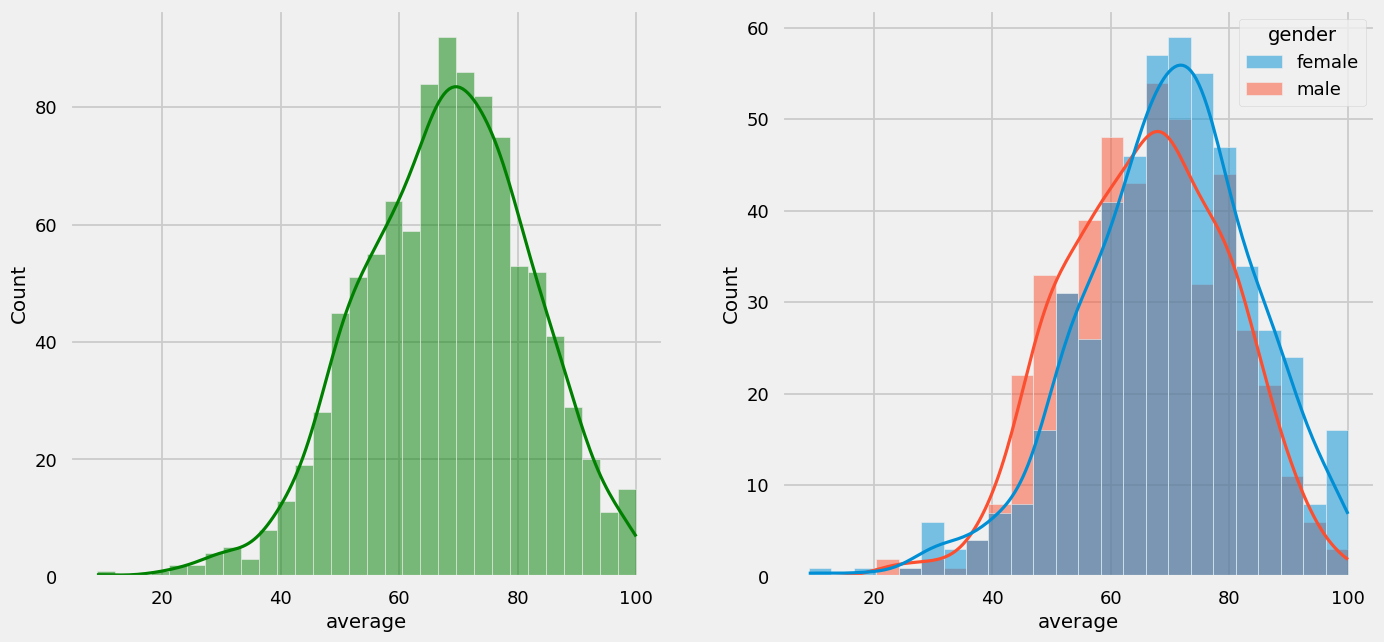

In [135]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

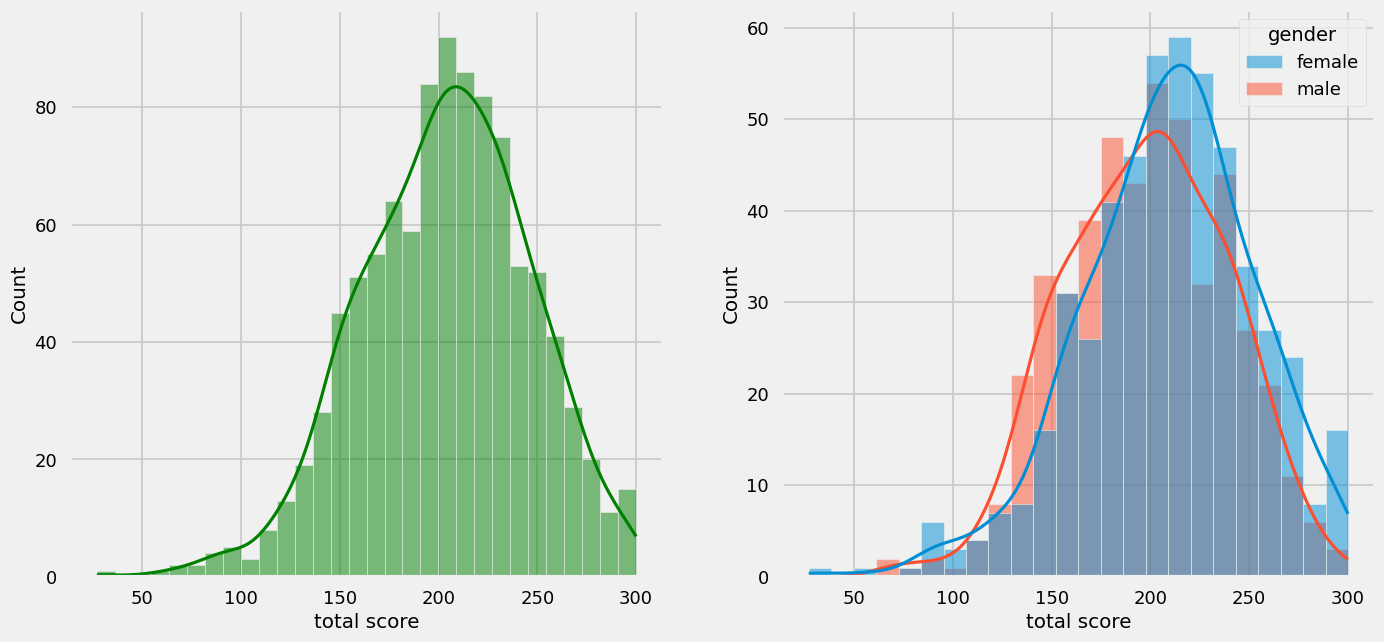

In [136]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

#####  Insights
- Female students tend to perform well then male students.

In [137]:

# ============================================================
# CREATE AVERAGE SCORE
# ============================================================

df["average"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

# Verify
print("Average column created successfully.")
print(df[["math score", "reading score", "writing score", "average"]].head())


Average column created successfully.
   math score  reading score  writing score  average
0          72             72             74    72.67
1          69             90             88    82.33
2          90             95             93    92.67
3          47             57             44    49.33
4          76             78             75    76.33


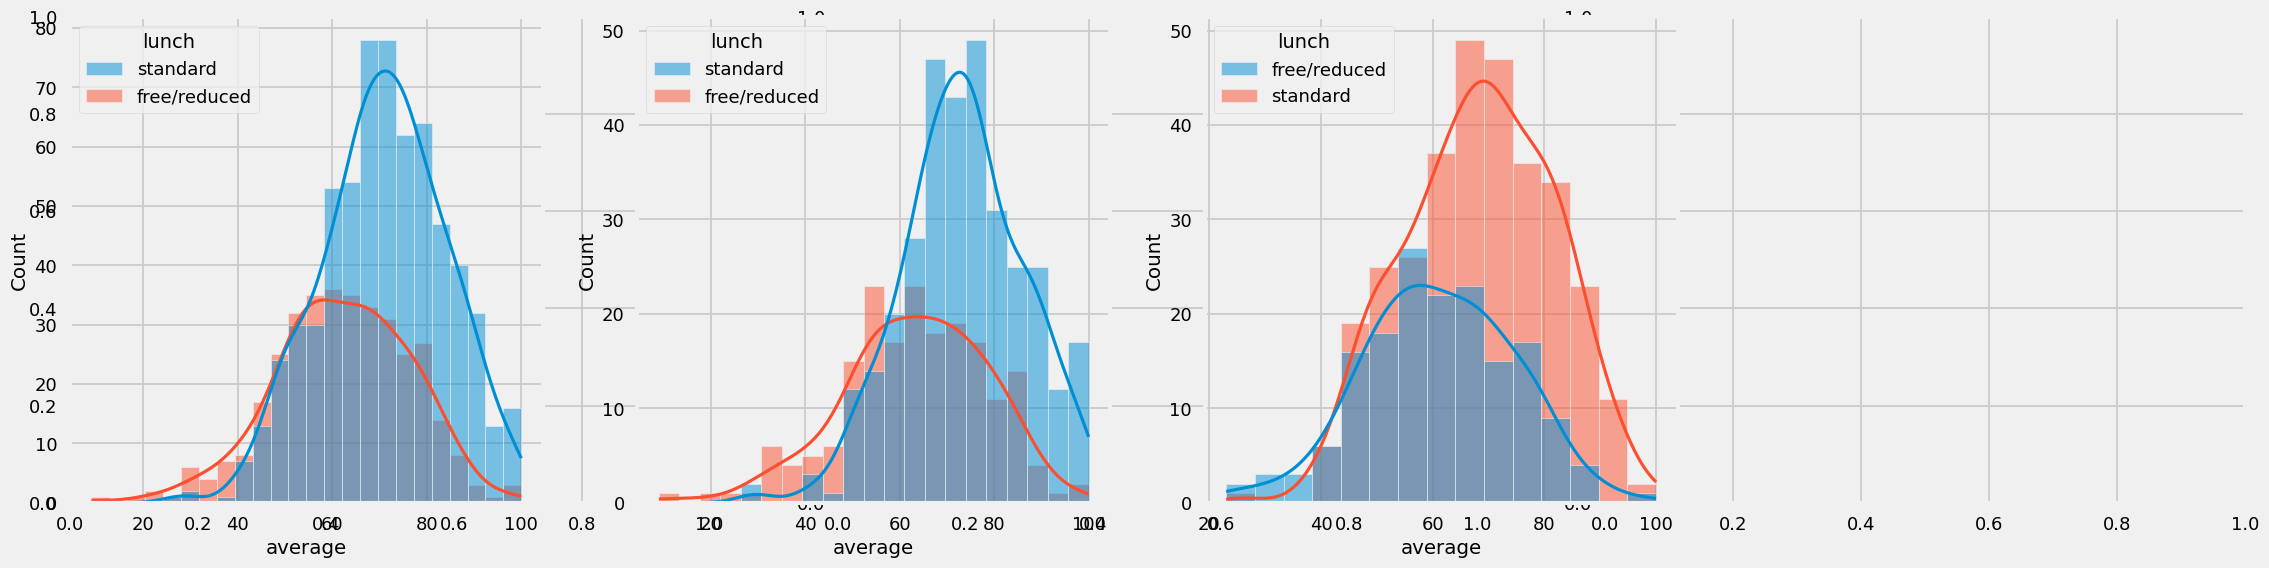

In [138]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

In [139]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test preparation course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

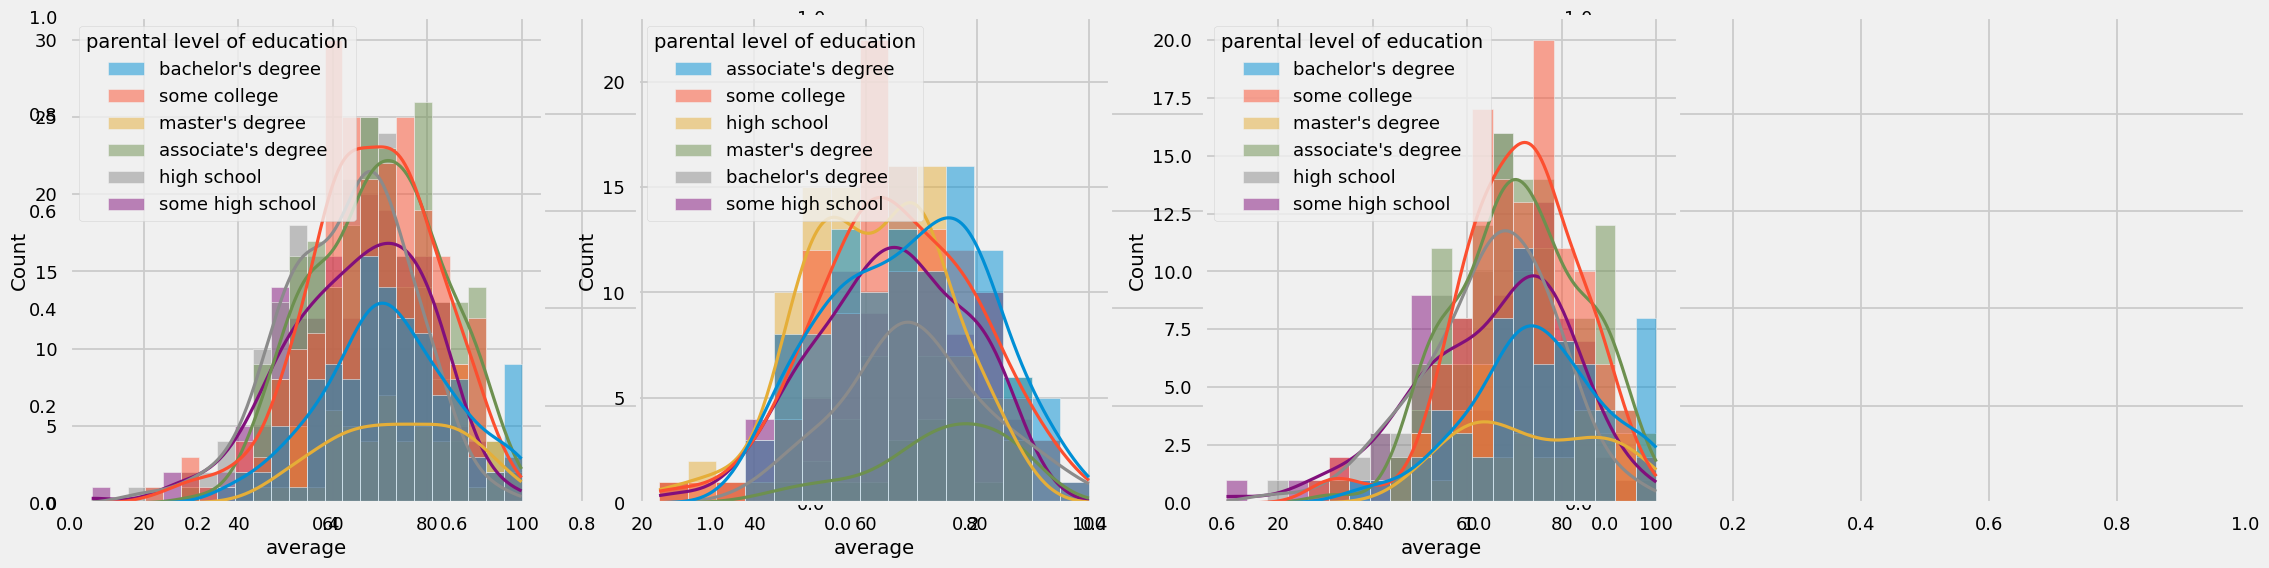

In [140]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental level of education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental level of education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental level of education')
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

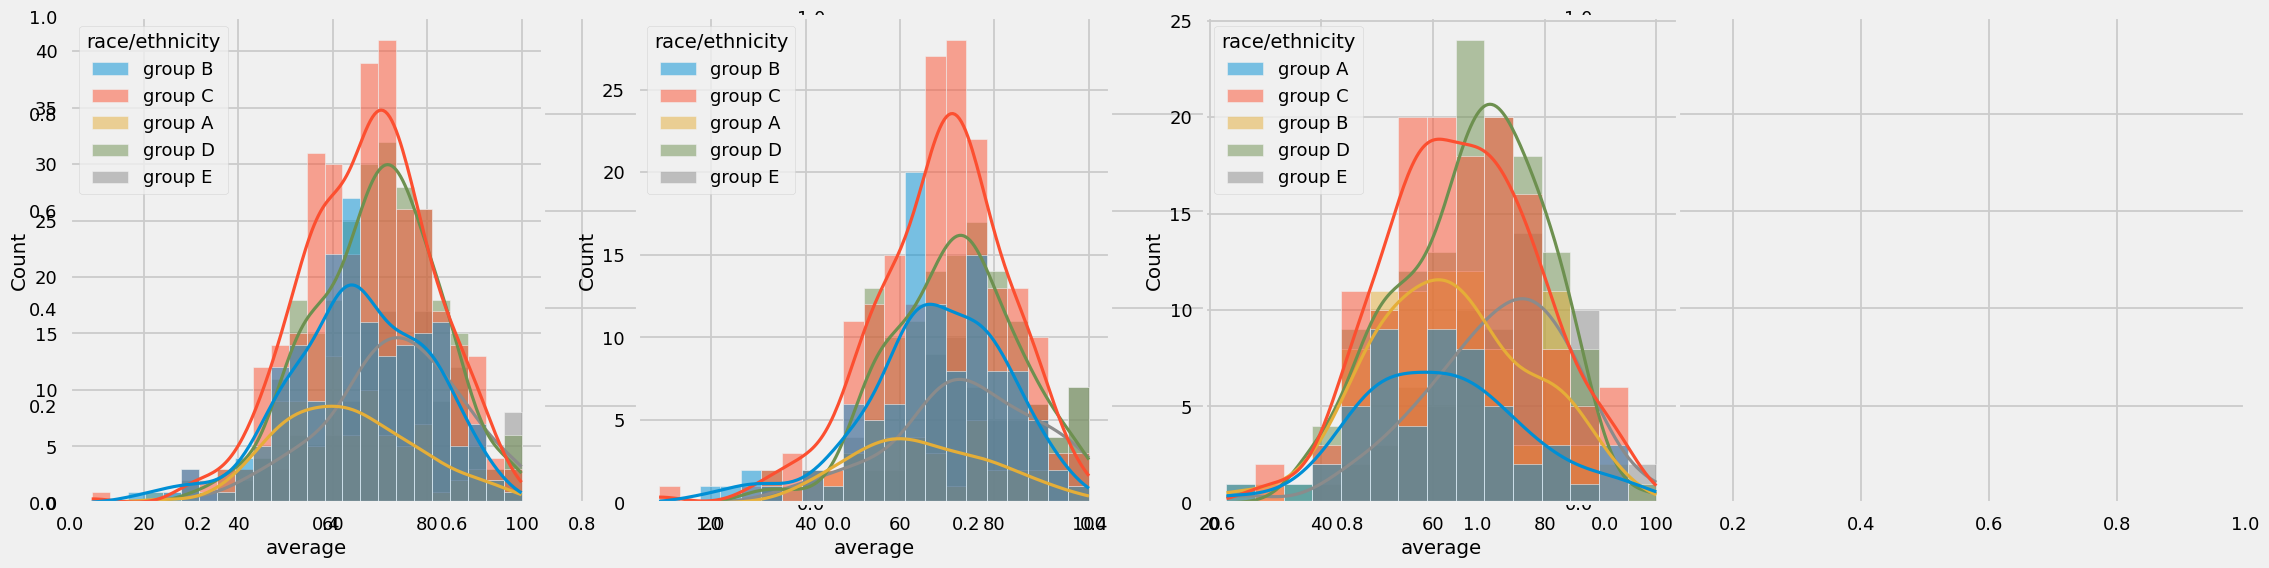

In [141]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.2 Maximumum score of students in all three subjects

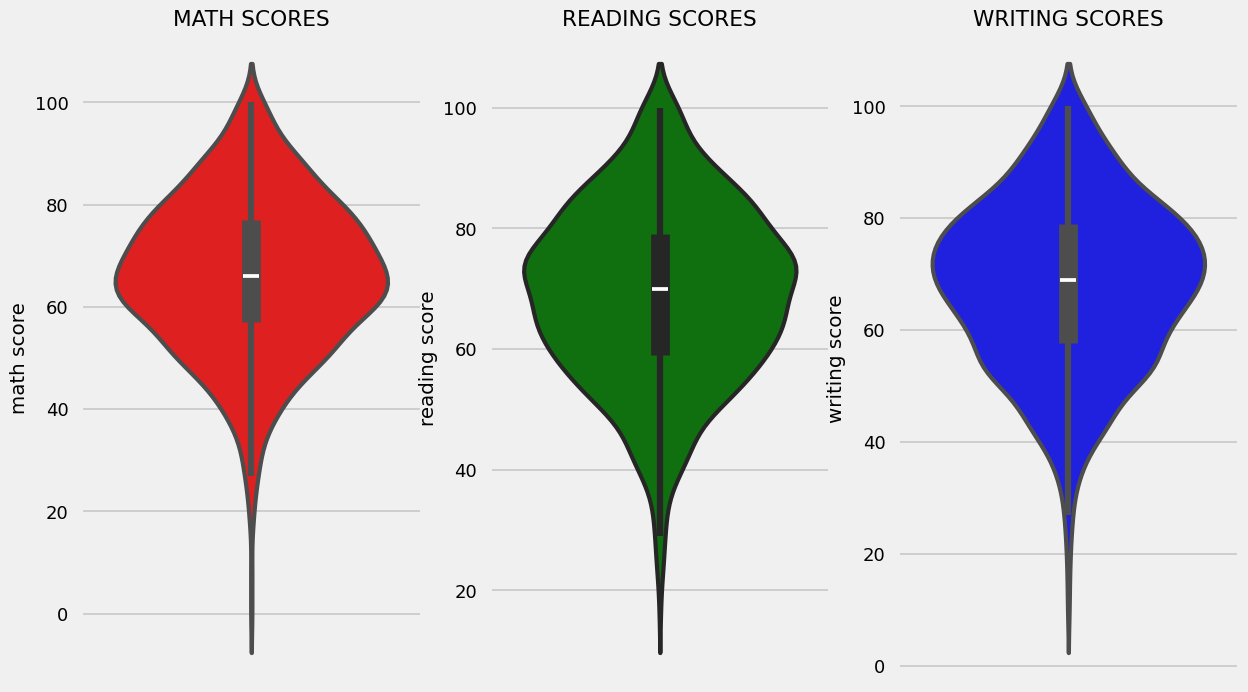

In [142]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### 4.3 Multivariate analysis using pieplot

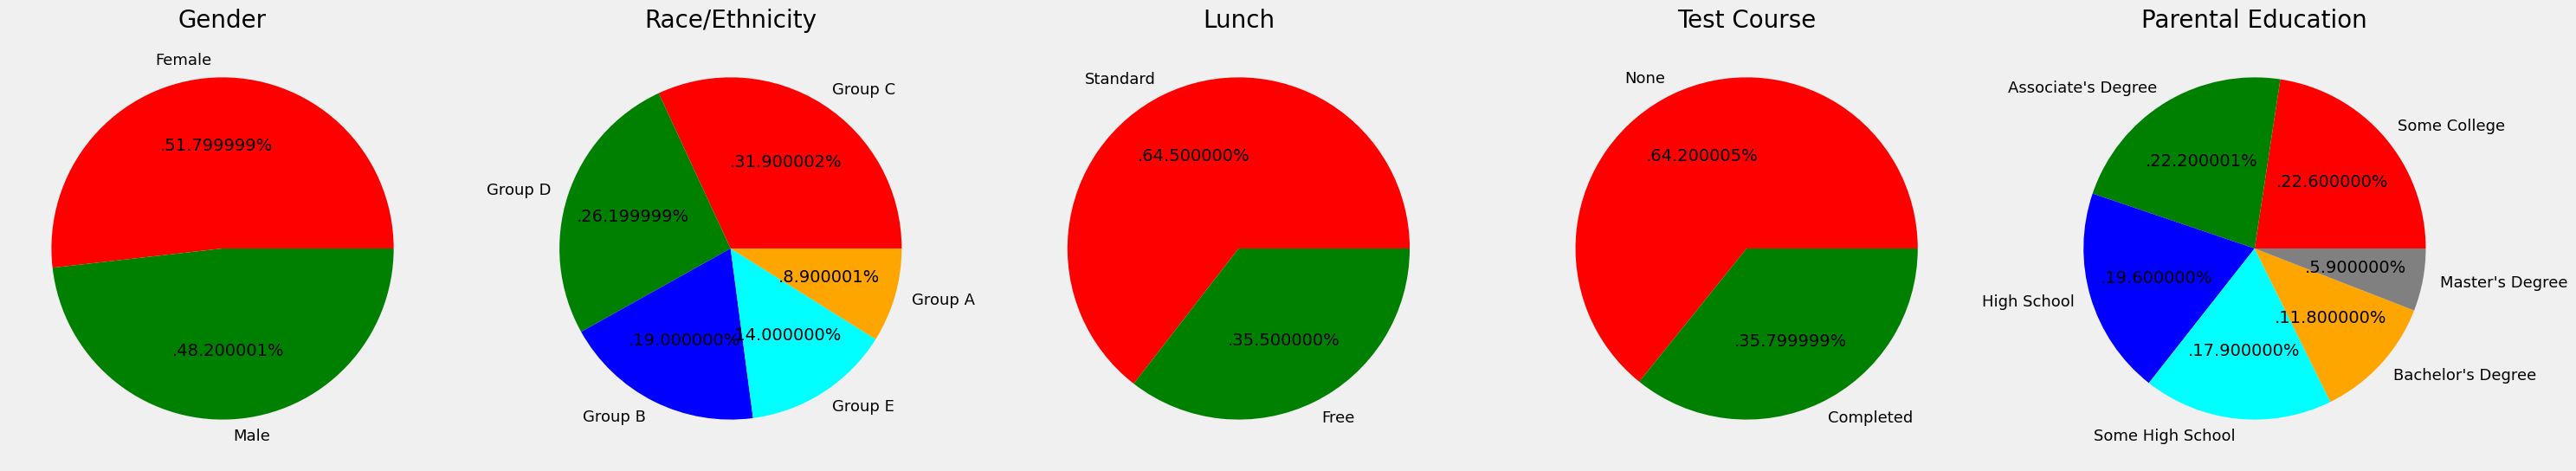

In [143]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

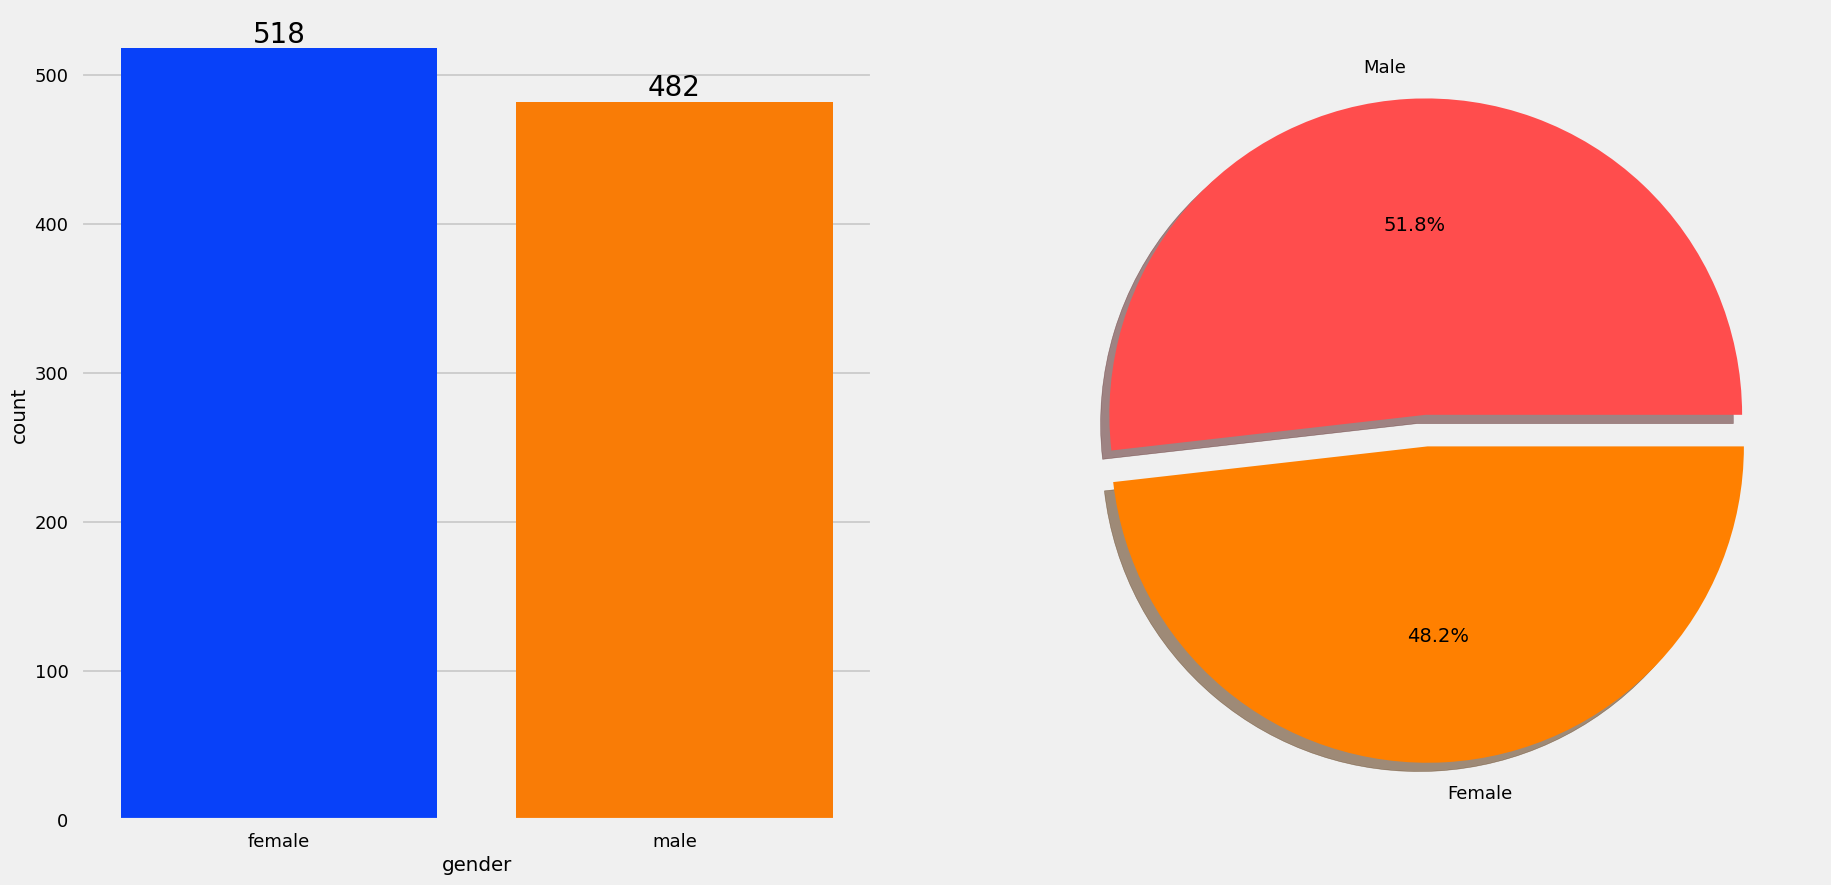

In [144]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [145]:
gender_group = df.groupby('gender').mean(numeric_only=True)

gender_group

,math score,reading score,writing score,average,total score
gender,,,,,
female,63.63,72.61,72.47,69.57,208.71
male,68.73,65.47,63.31,65.84,197.51


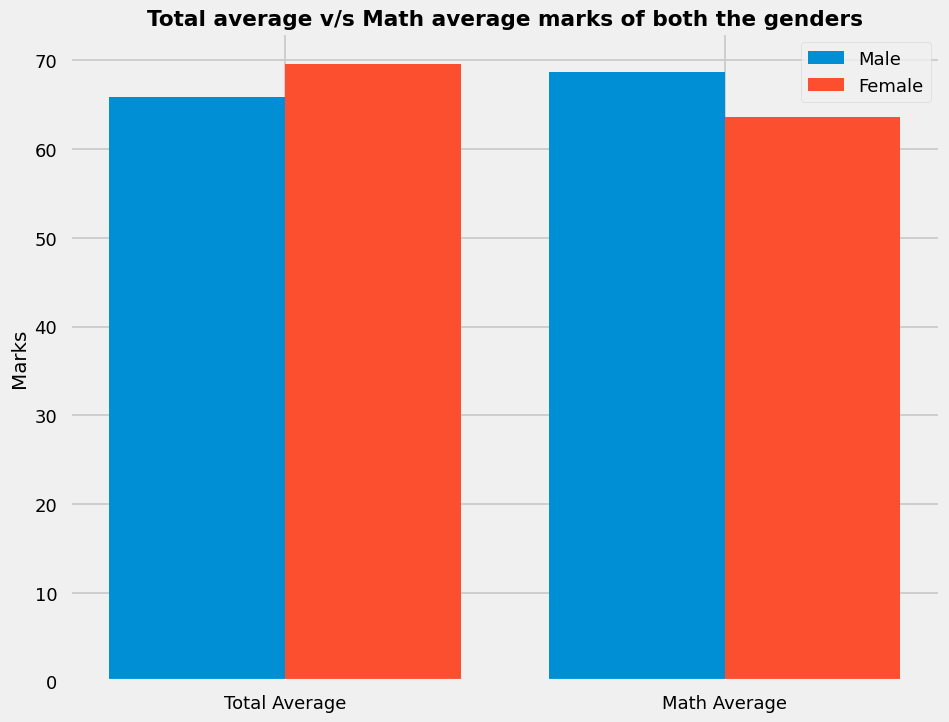

In [146]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average'][0], gender_group['math score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

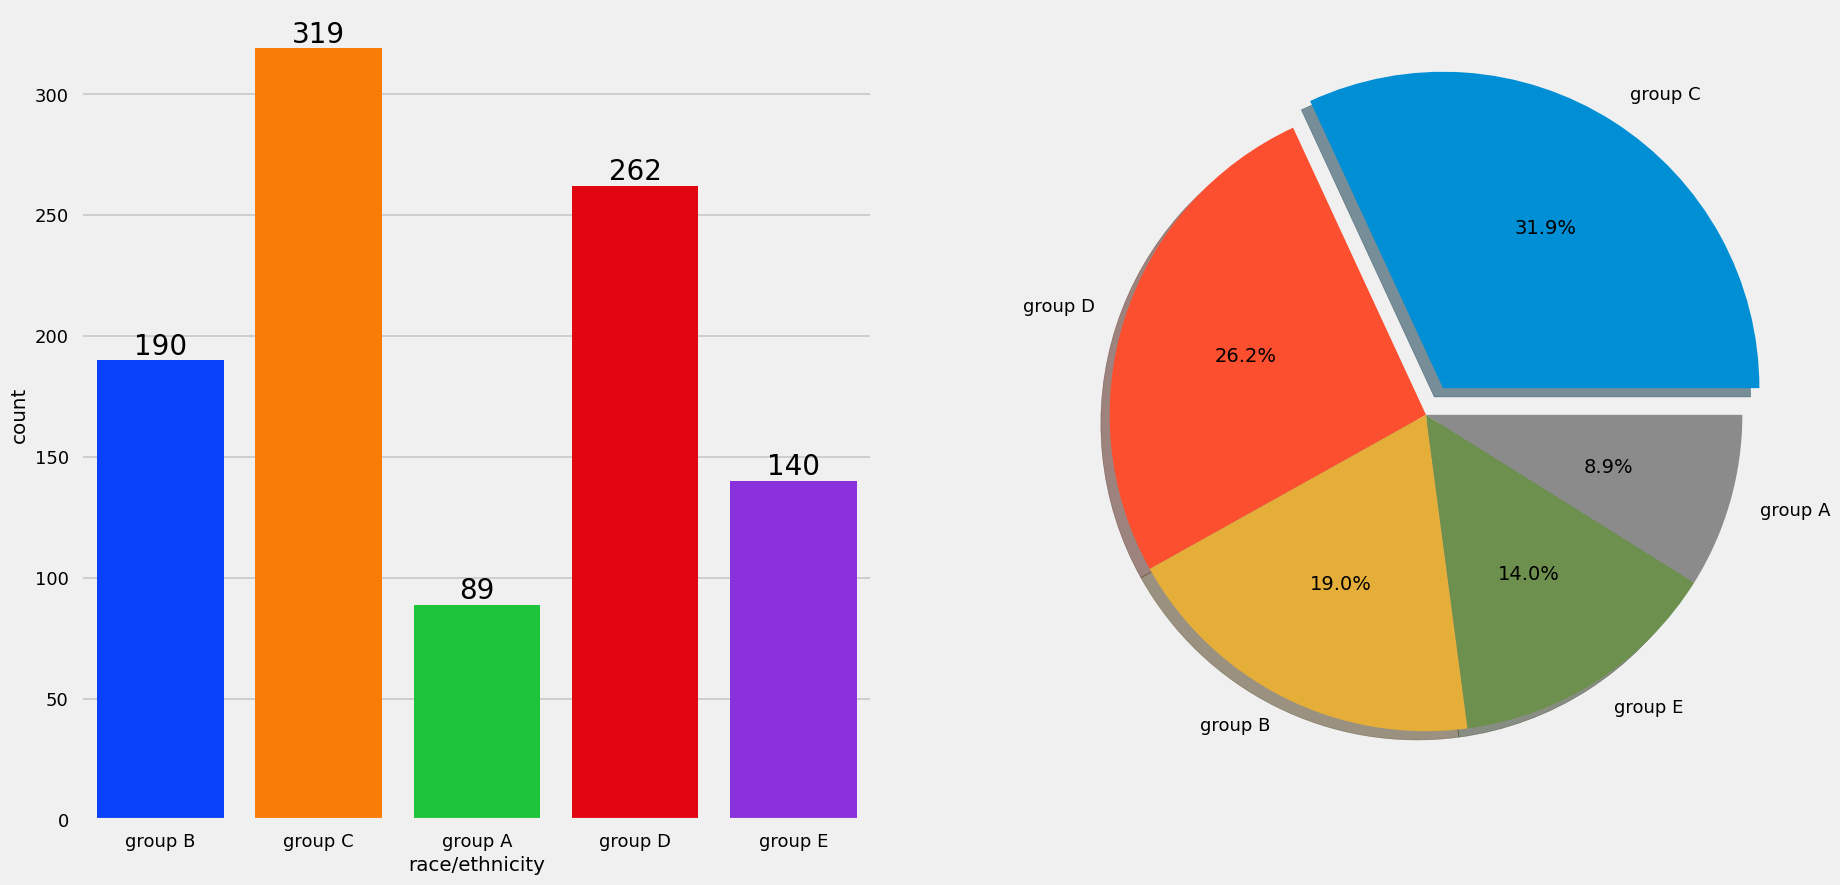

In [147]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

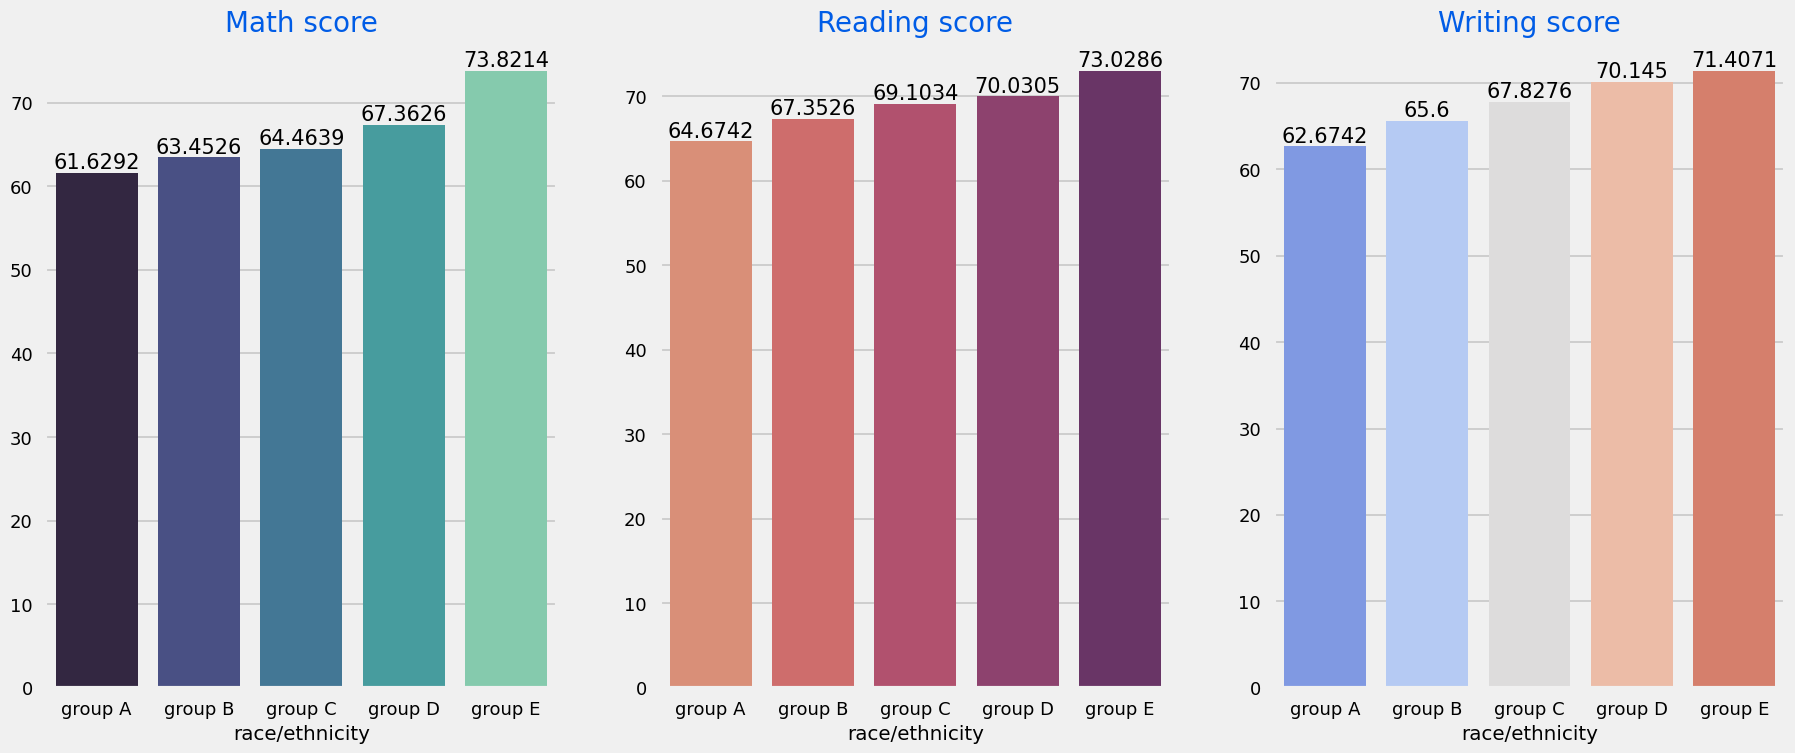

In [148]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

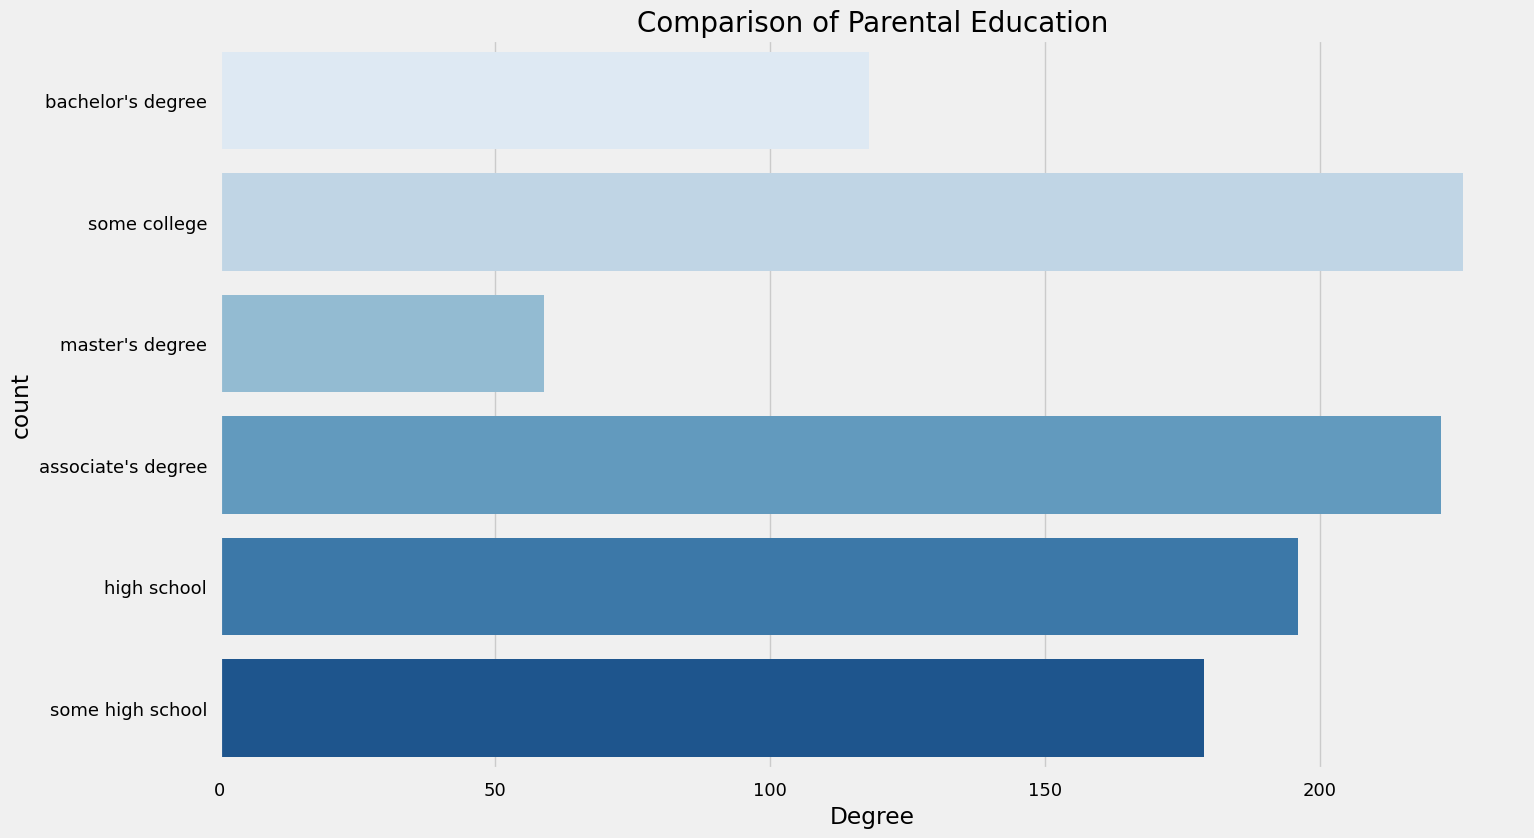

In [149]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

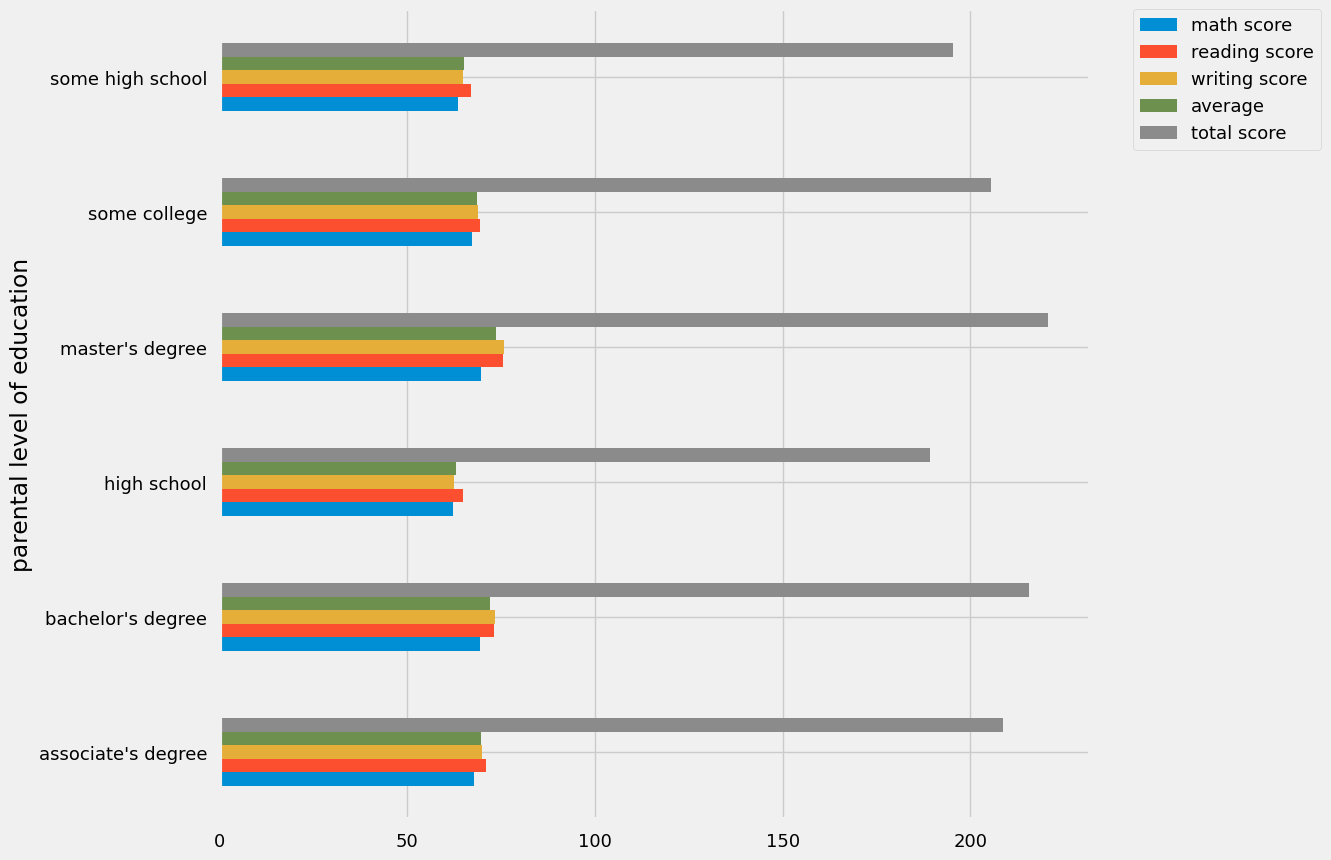

In [150]:
df.groupby('parental level of education').mean(
    numeric_only=True
).plot(
    kind='barh',
    figsize=(10, 10)
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.
)

plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

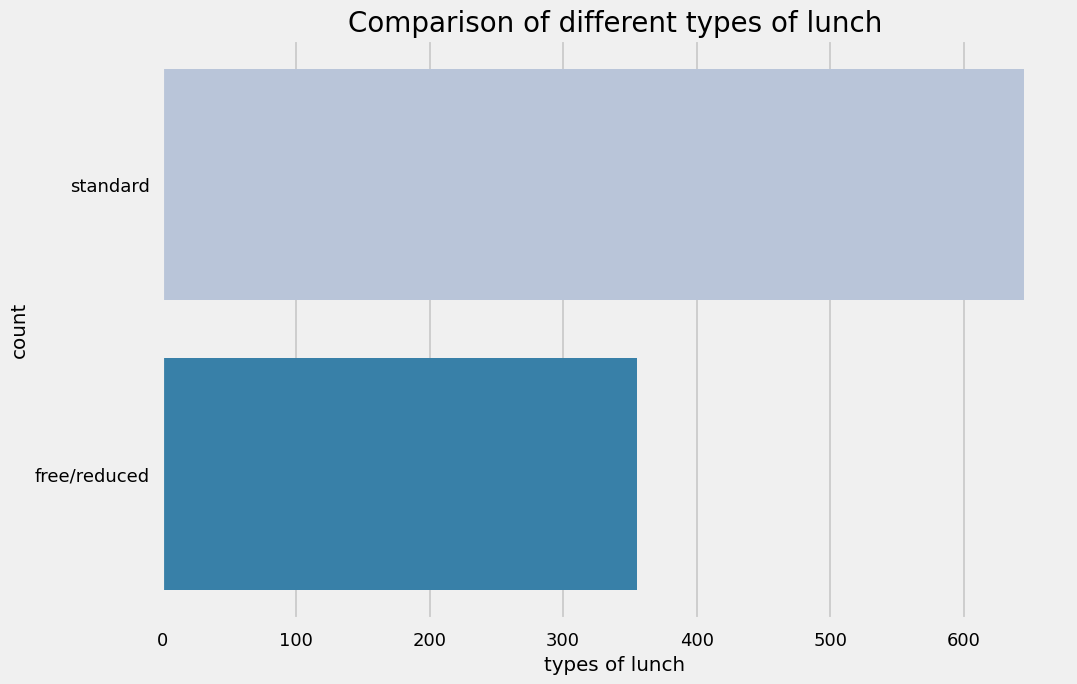

In [151]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

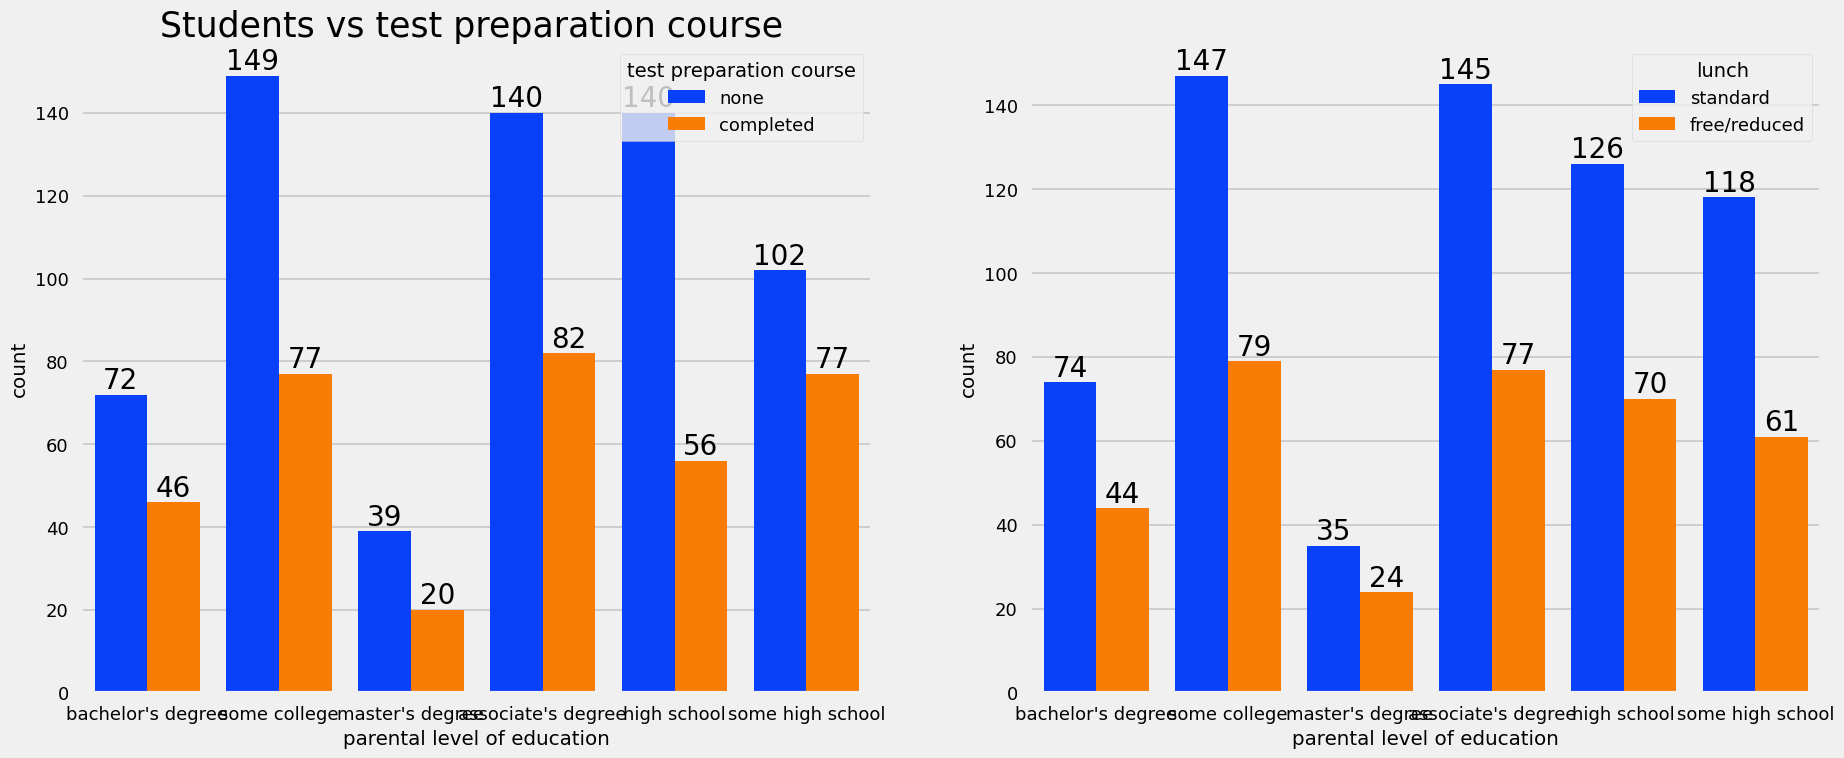

In [152]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

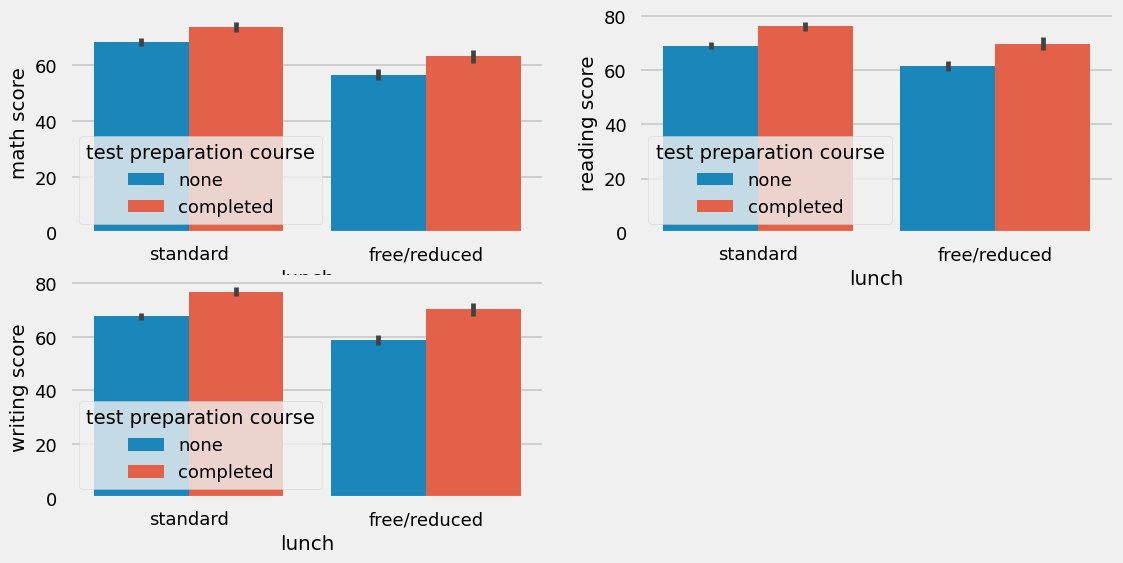

In [153]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

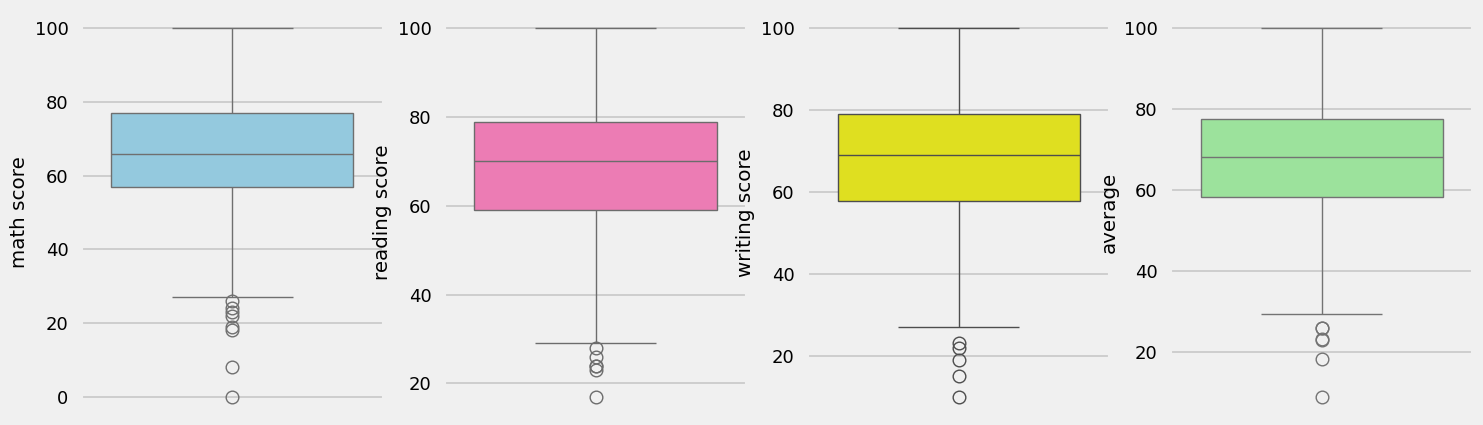

In [154]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

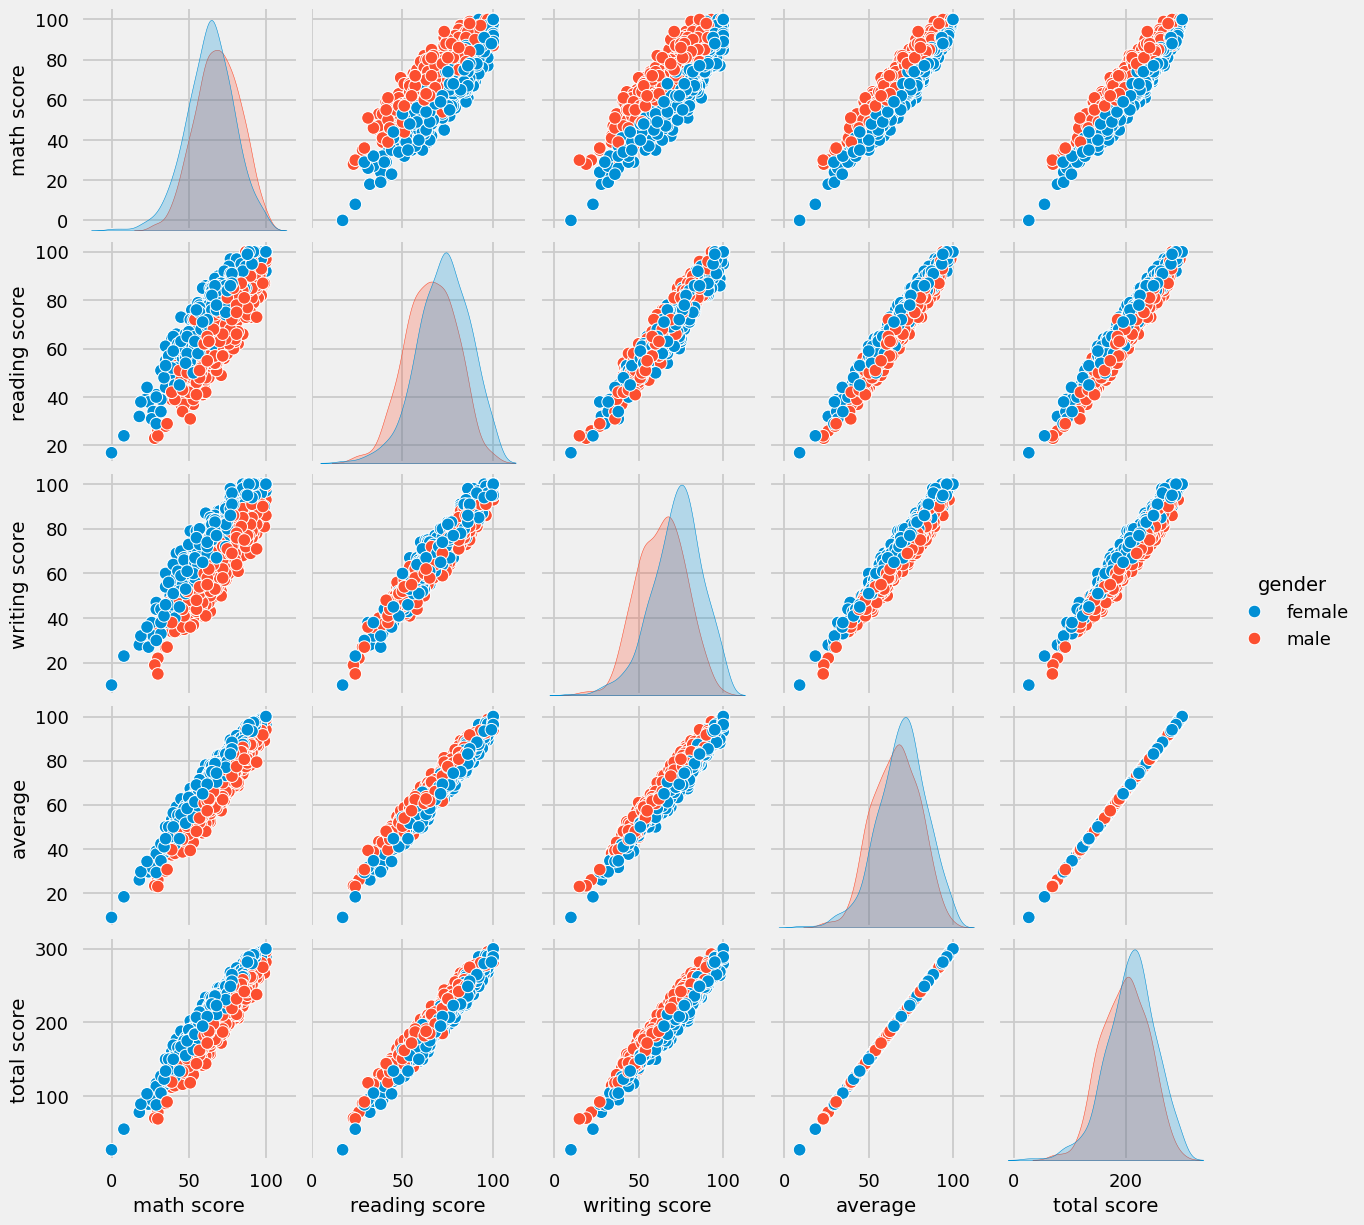

In [155]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.

# 🚀 Production-Grade Interactive EDA with Plotly

This section upgrades the original static EDA into an interactive, reusable analysis layer.

### What is added
- Robust data validation and profiling
- Feature engineering with clearly defined metrics
- Executive KPI view
- Interactive score distributions and subject comparisons
- Category-level performance analysis with sample sizes
- Box/violin views for spread and outliers
- Interactive correlation matrix
- Score-vs-score relationship analysis
- Cross-dimensional analysis of gender, lunch, parental education, ethnicity, and test preparation
- Automated outlier diagnostics
- Data-driven findings with statistical context
- Export-ready Plotly figures

> **Interpretation note:** differences between groups are descriptive associations in this dataset. They should not be interpreted as causal effects without an appropriate study design.


In [156]:
# Core interactive-EDA dependencies
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PLOTLY_TEMPLATE = "plotly_white"
SCORE_COLS = ["math score", "reading score", "writing score"]
CAT_COLS = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
]

REQUIRED_COLS = CAT_COLS + SCORE_COLS
missing_required = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Work on a clean analysis copy; keep the original df intact.
eda = df.copy()

for c in SCORE_COLS:
    eda[c] = pd.to_numeric(eda[c], errors="coerce")

eda["total score"] = eda[SCORE_COLS].sum(axis=1)
eda["average"] = eda[SCORE_COLS].mean(axis=1)
eda["score spread"] = eda[SCORE_COLS].max(axis=1) - eda[SCORE_COLS].min(axis=1)

# Useful, descriptive performance bands.
eda["performance_band"] = pd.cut(
    eda["average"],
    bins=[-np.inf, 49.999, 59.999, 69.999, 79.999, np.inf],
    labels=["<50", "50–59", "60–69", "70–79", "80+"],
    right=True,
)

# Preserve explicit category ordering where it improves chart readability.
edu_order = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree",
]
for c in CAT_COLS:
    eda[c] = eda[c].astype("string").str.strip()

eda["parental level of education"] = pd.Categorical(
    eda["parental level of education"],
    categories=edu_order,
    ordered=True,
)

# Validation report
validation = pd.DataFrame({
    "rows": [len(eda)],
    "columns": [eda.shape[1]],
    "missing_cells": [int(eda.isna().sum().sum())],
    "duplicate_rows": [int(eda.duplicated().sum())],
    "score_range_violations": [
        int(((eda[SCORE_COLS] < 0) | (eda[SCORE_COLS] > 100)).sum().sum())
    ],
})
display(validation)


,rows,columns,missing_cells,duplicate_rows,score_range_violations
0,1000,12,0,0,0


In [157]:
# Executive KPI dashboard
n_students = len(eda)
mean_scores = eda[SCORE_COLS].mean()
overall_mean = eda["average"].mean()
median_mean = eda["average"].median()
completed_pct = (eda["test preparation course"].eq("completed").mean() * 100)
standard_lunch_pct = (eda["lunch"].eq("standard").mean() * 100)
high_performer_pct = (eda["average"].ge(80).mean() * 100)

fig = go.Figure()
kpis = [
    ("Students", n_students, "", ".0f"),
    ("Overall average", overall_mean, " pts", ".1f"),
    ("Median average", median_mean, " pts", ".1f"),
    ("Test prep completed", completed_pct, "%", ".1f"),
    ("Standard lunch", standard_lunch_pct, "%", ".1f"),
    ("Average ≥ 80", high_performer_pct, "%", ".1f"),
]

for i, (label, value, suffix, fmt) in enumerate(kpis):
    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        number={"suffix": suffix, "valueformat": fmt},
        title={"text": label},
        domain={"row": 0, "column": i},
    ))

fig.update_layout(
    template=PLOTLY_TEMPLATE,
    grid={"rows": 1, "columns": len(kpis)},
    height=220,
    margin={"t": 40, "b": 10, "l": 10, "r": 10},
    title="Student Performance — Executive Snapshot",
)
fig.show()


In [158]:
# 1) Score distribution: all subjects in one interactive view
long_scores = eda.melt(
    id_vars=["gender", "race/ethnicity", "lunch", "test preparation course"],
    value_vars=SCORE_COLS,
    var_name="subject",
    value_name="score",
)

fig = px.histogram(
    long_scores,
    x="score",
    facet_col="subject",
    color="gender",
    nbins=30,
    barmode="overlay",
    opacity=0.65,
    marginal="box",
    histnorm="probability density",
    template=PLOTLY_TEMPLATE,
    title="Score Distributions by Subject and Gender",
    labels={"score": "Score", "subject": "Subject"},
)
fig.update_layout(height=520, legend_title_text="Gender")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1].title()))
fig.show()


In [159]:
# 2) Subject-level performance: mean + median + variability
subject_summary = pd.DataFrame({
    "Subject": ["Math", "Reading", "Writing"],
    "Mean": [eda[c].mean() for c in SCORE_COLS],
    "Median": [eda[c].median() for c in SCORE_COLS],
    "Std Dev": [eda[c].std() for c in SCORE_COLS],
    "Min": [eda[c].min() for c in SCORE_COLS],
    "Max": [eda[c].max() for c in SCORE_COLS],
})

fig = go.Figure()
fig.add_trace(go.Bar(
    x=subject_summary["Subject"],
    y=subject_summary["Mean"],
    error_y={"type": "data", "array": subject_summary["Std Dev"], "visible": True},
    text=subject_summary["Mean"].round(1),
    textposition="outside",
    name="Mean ± SD",
))
fig.add_trace(go.Scatter(
    x=subject_summary["Subject"],
    y=subject_summary["Median"],
    mode="markers+lines",
    name="Median",
    marker={"size": 10},
))
fig.update_layout(
    template=PLOTLY_TEMPLATE,
    title="Subject Performance: Mean, Median and Variability",
    yaxis_title="Score",
    xaxis_title="",
    yaxis={"range": [0, 105]},
    height=500,
)
fig.show()
display(subject_summary.round(2))


,Subject,Mean,Median,Std Dev,Min,Max
0,Math,66.09,66.00,15.16,0,100
1,Reading,69.17,70.00,14.60,17,100
2,Writing,68.05,69.00,15.20,10,100


In [160]:
# 3) Interactive categorical performance explorer
# Change GROUP_BY and METRIC to reuse this cell for different business questions.
GROUP_BY = "test preparation course"
METRIC = "average"

grouped = (
    eda.groupby(GROUP_BY, observed=True)
       .agg(
           students=(METRIC, "size"),
           mean_score=(METRIC, "mean"),
           median_score=(METRIC, "median"),
           std_dev=(METRIC, "std"),
       )
       .reset_index()
       .sort_values("mean_score", ascending=False)
)

fig = px.bar(
    grouped,
    x=GROUP_BY,
    y="mean_score",
    text="mean_score",
    error_y="std_dev",
    hover_data=["students", "median_score"],
    template=PLOTLY_TEMPLATE,
    title=f"{METRIC.title()} by {GROUP_BY.replace('_', ' ').title()}",
)
fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
fig.update_layout(yaxis_title="Average score", xaxis_title="")
fig.show()

display(grouped.round(2))


,test preparation course,students,mean_score,median_score,std_dev
0,completed,358,72.67,73.50,13.04
1,none,642,65.04,65.33,14.19


In [161]:
# 4) Multi-factor performance matrix
# Compare average score across two categorical dimensions.
X_GROUP = "lunch"
Y_GROUP = "test preparation course"

heat = (
    eda.pivot_table(
        index=Y_GROUP,
        columns=X_GROUP,
        values="average",
        aggfunc="mean",
        observed=True,
    )
)

fig = px.imshow(
    heat,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    template=PLOTLY_TEMPLATE,
    title=f"Average Score Matrix: {Y_GROUP.title()} × {X_GROUP.title()}",
    labels={"color": "Average score"},
)
fig.update_layout(height=430)
fig.show()

display(heat.round(2))


lunch,free/reduced,standard
test preparation course,,
completed,67.76,75.51
none,58.95,68.30


In [162]:
# 5) Distribution + outlier analysis by key categorical features
FEATURES = ["gender", "lunch", "test preparation course"]

for feature in FEATURES:
    fig = px.violin(
        eda,
        x=feature,
        y="average",
        color=feature,
        box=True,
        points="outliers",
        hover_data=["math score", "reading score", "writing score"],
        template=PLOTLY_TEMPLATE,
        title=f"Average Score Distribution by {feature.title()}",
    )
    fig.update_layout(
        showlegend=False,
        yaxis_title="Average score",
        xaxis_title="",
        height=470,
    )
    fig.show()


In [163]:
# 6) Parent education and ethnicity: ordered group comparisons
# Horizontal charts make long category labels easier to read.
for feature, title in [
    ("parental level of education", "Parental Education"),
    ("race/ethnicity", "Race / Ethnicity Group"),
]:
    summary = (
        eda.groupby(feature, observed=True)
           .agg(
               students=("average", "size"),
               mean_average=("average", "mean"),
               median_average=("average", "median"),
           )
           .reset_index()
           .sort_values("mean_average")
    )

    fig = px.bar(
        summary,
        x="mean_average",
        y=feature,
        orientation="h",
        text="mean_average",
        hover_data=["students", "median_average"],
        template=PLOTLY_TEMPLATE,
        title=f"Average Performance by {title}",
    )
    fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
    fig.update_layout(
        xaxis_title="Mean average score",
        yaxis_title="",
        height=500,
    )
    fig.show()


In [164]:
# 7) Subject correlation matrix
corr = eda[SCORE_COLS + ["total score", "average"]].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    zmin=-1,
    zmax=1,
    color_continuous_scale="RdBu_r",
    aspect="auto",
    template=PLOTLY_TEMPLATE,
    title="Correlation Matrix — Subject and Aggregate Scores",
)
fig.update_layout(height=560)
fig.show()

display(corr.round(3))


,math score,reading score,writing score,total score,average
math score,1.00,0.82,0.80,0.92,0.92
reading score,0.82,1.00,0.95,0.97,0.97
writing score,0.80,0.95,1.00,0.97,0.97
total score,0.92,0.97,0.97,1.00,1.00
average,0.92,0.97,0.97,1.00,1.00


In [165]:
# 8) Pairwise relationship explorer with marginal distributions
fig = px.scatter(
    eda,
    x="reading score",
    y="writing score",
    color="gender",
    symbol="test preparation course",
    size="average",
    size_max=16,
    hover_data=[
        "race/ethnicity",
        "parental level of education",
        "lunch",
        "math score",
        "average",
    ],
    marginal_x="box",
    marginal_y="box",
    template=PLOTLY_TEMPLATE,
    title="Reading vs Writing Performance",
)
x = eda["reading score"].to_numpy(dtype=float)
y = eda["writing score"].to_numpy(dtype=float)
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

fig.add_trace(go.Scatter(
    x=x_line,
    y=slope * x_line + intercept,
    mode="lines",
    name=f"OLS trend (slope={slope:.2f})",
    line={"dash": "dash"},
))
fig.update_layout(height=650)
fig.show()


In [166]:
# 9) Gender × subject profile
gender_subject = (
    eda.groupby("gender")[SCORE_COLS]
       .mean()
       .T
       .reset_index()
       .rename(columns={"index": "subject"})
)

long_gender = gender_subject.melt(
    id_vars="subject",
    var_name="gender",
    value_name="mean_score",
)

fig = px.line(
    long_gender,
    x="subject",
    y="mean_score",
    color="gender",
    markers=True,
    template=PLOTLY_TEMPLATE,
    title="Subject Performance Profile by Gender",
)
fig.update_yaxes(range=[0, 100], title="Mean score")
fig.update_xaxes(title="")
fig.show()

display(long_gender.pivot(index="subject", columns="gender", values="mean_score").round(2))


gender,female,male
subject,,
math score,63.63,68.73
reading score,72.61,65.47
writing score,72.47,63.31


In [167]:
# 10) Test-preparation effect — descriptive gap, not causal impact
prep_summary = (
    eda.groupby("test preparation course", observed=True)
       .agg(
           students=("average", "size"),
           math_mean=("math score", "mean"),
           reading_mean=("reading score", "mean"),
           writing_mean=("writing score", "mean"),
           average_mean=("average", "mean"),
       )
       .reset_index()
)

fig = px.bar(
    prep_summary.melt(
        id_vars=["test preparation course", "students"],
        value_vars=["math_mean", "reading_mean", "writing_mean", "average_mean"],
        var_name="metric",
        value_name="score",
    ),
    x="metric",
    y="score",
    color="test preparation course",
    barmode="group",
    text="score",
    hover_data=["students"],
    template=PLOTLY_TEMPLATE,
    title="Performance by Test Preparation Status",
)
fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
fig.update_layout(yaxis_title="Mean score", xaxis_title="", height=520)
fig.show()

display(prep_summary.round(2))


,test preparation course,students,math_mean,reading_mean,writing_mean,average_mean
0,completed,358,69.70,73.89,74.42,72.67
1,none,642,64.08,66.53,64.50,65.04


In [168]:
# 11) Automated IQR outlier diagnostics
outlier_rows = []
for col in SCORE_COLS + ["average", "total score"]:
    q1, q3 = eda[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (eda[col] < lower) | (eda[col] > upper)
    outlier_rows.append({
        "metric": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_fence": lower,
        "upper_fence": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": mask.mean() * 100,
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)

fig = px.bar(
    outlier_report,
    x="metric",
    y="outlier_count",
    text="outlier_count",
    hover_data=["outlier_pct", "lower_fence", "upper_fence"],
    template=PLOTLY_TEMPLATE,
    title="IQR-Based Outlier Counts",
)
fig.update_traces(textposition="outside")
fig.update_layout(yaxis_title="Number of observations", xaxis_title="")
fig.show()

display(outlier_report.round(2))


,metric,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count,outlier_pct
0,math score,57.00,77.00,20.00,27.00,107.00,8,0.80
1,reading score,59.00,79.00,20.00,29.00,109.00,6,0.60
3,average,58.33,77.67,19.33,29.33,106.67,6,0.60
4,total score,175.00,233.00,58.00,88.00,320.00,6,0.60
2,writing score,57.75,79.00,21.25,25.88,110.88,5,0.50


In [169]:
# 12) High-dimensional interactive profile
# Each point is a student; hover reveals the full profile.
profile_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "math score",
    "reading score",
    "writing score",
    "average",
    "performance_band",
]

fig = px.scatter(
    eda,
    x="math score",
    y="reading score",
    color="average",
    symbol="test preparation course",
    hover_data=profile_cols,
    color_continuous_scale="Viridis",
    template=PLOTLY_TEMPLATE,
    title="Student-Level Interactive Performance Map",
)
fig.update_layout(height=650)
fig.show()


## Evidence-based findings from the current notebook outputs

The saved analysis already establishes several data-quality facts:

- **1,000 observations and 8 original variables**
- **No missing values**
- **No duplicate rows**
- Math mean ≈ **66.09**, reading mean ≈ **69.17**, writing mean ≈ **68.05**
- Reading and writing have higher average scores than math in the supplied data
- Female students have a higher overall average than male students in the saved group summary, while male students have a higher mean math score
- Full marks are more common in reading/writing than math in the supplied data

### Important analytical corrections

1. **Do not infer causality from group differences.** For example, students who completed test preparation may have higher scores, but this dataset alone does not establish that the course caused the difference.
2. **Avoid treating race/ethnicity as a direct causal mechanism.** The dataset only contains anonymized group labels and does not provide enough contextual variables to explain observed differences.
3. **Lunch should be treated as an observed socioeconomic proxy, not a direct measure of socioeconomic status.**
4. **Use both center and spread.** Mean differences can hide substantial overlap between groups; the violin/box plots above make that overlap visible.
5. **Correlation is not causation.** Strong correlations among math, reading, and writing scores indicate that performance moves together, not why it does so.


## Production notes

This EDA layer is designed to be reusable:

- All derived metrics are created in a separate `eda` DataFrame.
- Required columns are validated before analysis.
- Score bounds are checked for invalid values.
- Category sample sizes are surfaced alongside group means.
- Interactive Plotly figures support hover-based inspection.
- The analysis avoids relying on fixed row positions or category counts.
- The notebook can be moved between local/Jupyter/Kaggle environments by updating the data path candidates rather than rewriting the analysis.

**Recommended next step:** if this notebook will be used for a portfolio or production analytics project, keep this EDA section and move the older exploratory Matplotlib/Seaborn cells into an appendix to reduce duplication.


## ⚠️ Execution order

Run the notebook **from top to bottom**. The production loader is schema-aware and will select the compatible `stud.csv` automatically. Do not manually overwrite `df` before the Extreme EDA section.


# 🔬 Extreme Production-Level EDA — Statistical, Interactive & Diagnostic Layer

This section **extends the complete original notebook without removing any previous analysis**.

It adds a production-oriented EDA framework covering:

- data-contract validation and quality scoring
- automated schema and cardinality profiling
- missingness / duplicate / range / integrity diagnostics
- advanced feature engineering
- score bands, gaps, balance and consistency metrics
- interactive Plotly dashboards
- distribution, ECDF, box, violin and ridge-style views
- categorical × numerical drill-downs
- multidimensional heatmaps and sunburst analysis
- subject dominance / weakness analysis
- correlation, rank-correlation and relationship diagnostics
- bootstrap confidence intervals
- effect sizes
- non-parametric and parametric statistical tests where appropriate
- outlier severity and influence diagnostics
- subgroup sample-size stability
- Pareto analysis
- student-level risk / excellence segmentation
- automated findings and executive summary tables

**Interpretation rule:** group differences are descriptive associations in this observational dataset; they should not be interpreted as causal effects.


In [170]:
# ============================================================
# EXTREME EDA 0 — Production imports, theme and reproducibility
# ============================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from IPython.display import display, Markdown

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Consistent Plotly styling without hard-coding chart colors.
PLOTLY_TEMPLATE = "plotly_white"
px.defaults.template = PLOTLY_TEMPLATE
px.defaults.height = 520

print("Plotly:", __import__("plotly").__version__)
print("Rows:", len(df), "| Columns:", len(df.columns))


Plotly: 5.24.1
Rows: 1000 | Columns: 10


In [171]:
# ============================================================
# EXTREME EDA 1 — Data contract / schema validation
# ============================================================
EXPECTED_COLUMNS = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "math score",
    "reading score",
    "writing score",
]

# This guards against running this cell before the production loader.
current_columns = set(str(c).strip().lower() for c in df.columns)
missing_expected = sorted(set(EXPECTED_COLUMNS) - current_columns)
unexpected_columns = sorted(current_columns - set(EXPECTED_COLUMNS))

if missing_expected:
    raise RuntimeError(
        "The current `df` does not contain the expected student-performance schema.\n\n"
        f"Current columns: {list(df.columns)}\n"
        f"Missing expected columns: {missing_expected}\n\n"
        "Run the PRODUCTION DATA LOADER cell near the beginning of the notebook "
        "before running this EDA section."
    )

SCORE_COLS = ["math score", "reading score", "writing score"]
CAT_COLS = [c for c in EXPECTED_COLUMNS if c not in SCORE_COLS]

schema_rows = []
for c in df.columns:
    schema_rows.append({
        "column": c,
        "dtype": str(df[c].dtype),
        "rows": len(df),
        "missing": int(df[c].isna().sum()),
        "missing_pct": float(df[c].isna().mean() * 100),
        "unique": int(df[c].nunique(dropna=False)),
        "unique_pct": float(df[c].nunique(dropna=False) / len(df) * 100),
        "constant": bool(df[c].nunique(dropna=False) <= 1),
    })

schema_profile = pd.DataFrame(schema_rows)
display(schema_profile)

range_profile = pd.DataFrame({
    "min": df[SCORE_COLS].min(),
    "max": df[SCORE_COLS].max(),
    "invalid_below_0": (df[SCORE_COLS] < 0).sum(),
    "invalid_above_100": (df[SCORE_COLS] > 100).sum(),
})
display(range_profile)

print("Schema validation: PASS")


,column,dtype,rows,missing,missing_pct,unique,unique_pct,constant
0,gender,object,1000,0,0.00,2,0.20,False
1,race/ethnicity,object,1000,0,0.00,5,0.50,False
2,parental level of education,object,1000,0,0.00,6,0.60,False
3,lunch,object,1000,0,0.00,2,0.20,False
4,test preparation course,object,1000,0,0.00,2,0.20,False
5,math score,int64,1000,0,0.00,81,8.10,False
6,reading score,int64,1000,0,0.00,72,7.20,False
7,writing score,int64,1000,0,0.00,77,7.70,False
8,average,float64,1000,0,0.00,194,19.40,False
9,total score,int64,1000,0,0.00,194,19.40,False


,min,max,invalid_below_0,invalid_above_100
math score,0,100,0,0
reading score,17,100,0,0
writing score,10,100,0,0


Schema validation: PASS


In [172]:
# ============================================================
# EXTREME EDA 2 — Automated data-quality scorecard
# ============================================================
quality_checks = {
    "no_missing_values": int(df.isna().sum().sum() == 0),
    "no_duplicate_rows": int(df.duplicated().sum() == 0),
    "scores_within_0_100": int(((df[SCORE_COLS] >= 0) & (df[SCORE_COLS] <= 100)).all().all()),
    "expected_columns_present": int(not missing_expected),
    "no_constant_columns": int(not any(df[c].nunique(dropna=False) <= 1 for c in df.columns)),
}

quality_score = round(100 * np.mean(list(quality_checks.values())), 1)
quality_table = pd.DataFrame({
    "check": list(quality_checks.keys()),
    "passed": list(quality_checks.values()),
})
quality_table["status"] = np.where(quality_table["passed"].eq(1), "PASS", "REVIEW")

print(f"Overall automated data-quality score: {quality_score}/100")
display(quality_table)

if unexpected_columns:
    print("Review unexpected columns:", unexpected_columns)


Overall automated data-quality score: 100.0/100


,check,passed,status
0,no_missing_values,1,PASS
1,no_duplicate_rows,1,PASS
2,scores_within_0_100,1,PASS
3,expected_columns_present,1,PASS
4,no_constant_columns,1,PASS


Review unexpected columns: ['average', 'total score']


In [173]:
# ============================================================
# EXTREME EDA 3 — Feature engineering layer
# ============================================================
eda_ext = df.copy()

eda_ext["total_score"] = eda_ext[SCORE_COLS].sum(axis=1)
eda_ext["average_score"] = eda_ext[SCORE_COLS].mean(axis=1)
eda_ext["score_std"] = eda_ext[SCORE_COLS].std(axis=1)
eda_ext["score_range"] = eda_ext[SCORE_COLS].max(axis=1) - eda_ext[SCORE_COLS].min(axis=1)
eda_ext["lowest_subject"] = eda_ext[SCORE_COLS].idxmin(axis=1).str.replace("_score", "", regex=False)
eda_ext["highest_subject"] = eda_ext[SCORE_COLS].idxmax(axis=1).str.replace("_score", "", regex=False)

eda_ext["passed_all"] = (eda_ext[SCORE_COLS] >= 40).all(axis=1)
eda_ext["passed_math"] = eda_ext["math score"] >= 40
eda_ext["passed_reading"] = eda_ext["reading score"] >= 40
eda_ext["passed_writing"] = eda_ext["writing score"] >= 40

eda_ext["performance_band"] = pd.cut(
    eda_ext["average_score"],
    bins=[-np.inf, 39.999, 59.999, 79.999, np.inf],
    labels=["Needs Support", "Developing", "Proficient", "Advanced"],
)

eda_ext["consistency_band"] = pd.cut(
    eda_ext["score_std"],
    bins=[-np.inf, 5, 10, np.inf],
    labels=["Highly Consistent", "Moderately Consistent", "Variable"],
)

eda_ext["subject_gap_math_reading"] = eda_ext["math score"] - eda_ext["reading score"]
eda_ext["subject_gap_reading_writing"] = eda_ext["reading score"] - eda_ext["writing score"]
eda_ext["subject_gap_math_writing"] = eda_ext["math score"] - eda_ext["writing score"]

# A transparent, descriptive support flag — not a clinical or causal label.
eda_ext["support_flag"] = np.select(
    [
        eda_ext["average_score"] < 40,
        (eda_ext["average_score"] < 60) | (eda_ext["score_range"] >= 25),
        eda_ext["score_range"] >= 20,
    ],
    [
        "High Priority",
        "Monitor",
        "Subject Imbalance",
    ],
    default="Stable",
)

display(eda_ext.head())


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average,total score,total_score,average_score,score_std,score_range,lowest_subject,highest_subject,passed_all,passed_math,passed_reading,passed_writing,performance_band,consistency_band,subject_gap_math_reading,subject_gap_reading_writing,subject_gap_math_writing,support_flag
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67,218,218,72.67,1.15,2,math score,writing score,True,True,True,True,Proficient,Highly Consistent,0,-2,-2,Stable
1,female,group C,some college,standard,completed,69,90,88,82.33,247,247,82.33,11.59,21,math score,reading score,True,True,True,True,Advanced,Variable,-21,2,-19,Subject Imbalance
2,female,group B,master's degree,standard,none,90,95,93,92.67,278,278,92.67,2.52,5,math score,reading score,True,True,True,True,Advanced,Highly Consistent,-5,2,-3,Stable
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33,148,148,49.33,6.81,13,writing score,reading score,True,True,True,True,Developing,Moderately Consistent,-10,13,3,Monitor
4,male,group C,some college,standard,none,76,78,75,76.33,229,229,76.33,1.53,3,writing score,reading score,True,True,True,True,Proficient,Highly Consistent,-2,3,1,Stable


In [174]:
# ============================================================
# EXTREME EDA 4 — Executive KPI dashboard
# ============================================================
kpis = {
    "Students": len(eda_ext),
    "Overall mean": eda_ext["average_score"].mean(),
    "Overall median": eda_ext["average_score"].median(),
    "All-subject pass %": eda_ext["passed_all"].mean() * 100,
    "Mean score SD": eda_ext["average_score"].std(),
    "Mean subject gap": eda_ext["score_range"].mean(),
    "Completed prep %": eda_ext["test preparation course"].eq("completed").mean() * 100,
}

kpi_df = pd.DataFrame({
    "Metric": list(kpis.keys()),
    "Value": [round(v, 2) for v in kpis.values()]
})
display(kpi_df)

fig = go.Figure()
for i, (label, value) in enumerate(kpis.items()):
    suffix = "%" if "%" in label else ""
    fig.add_trace(go.Indicator(
        mode="number",
        value=float(value),
        number={"suffix": suffix, "valueformat": ".2f"},
        title={"text": label},
        domain={"row": i // 4, "column": i % 4},
    ))
fig.update_layout(
    grid={"rows": 2, "columns": 4, "pattern": "independent"},
    height=480,
    template=PLOTLY_TEMPLATE,
    title="Student Performance — Executive KPI View",
)
fig.show()


,Metric,Value
0,Students,"1,000.00"
1,Overall mean,67.77
2,Overall median,68.33
3,All-subject pass %,94.90
4,Mean score SD,14.26
5,Mean subject gap,9.79
6,Completed prep %,35.80


In [175]:
# ============================================================
# EXTREME EDA 5 — Full numerical profiling
# ============================================================
numeric_profile = eda_ext[SCORE_COLS + [
    "total_score", "average_score", "score_std", "score_range"
]].describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]).T

numeric_profile["skew"] = eda_ext[numeric_profile.index].skew()
numeric_profile["kurtosis"] = eda_ext[numeric_profile.index].kurtosis()
numeric_profile["zeros"] = (eda_ext[numeric_profile.index] == 0).sum()
display(numeric_profile.round(3))


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,skew,kurtosis,zeros
math score,"1,000.00",66.09,15.16,0.00,27.99,40.95,47.00,57.00,66.00,77.00,86.00,90.05,98.01,100.00,-0.28,0.28,1
reading score,"1,000.00",69.17,14.60,17.00,31.99,44.00,51.00,59.00,70.00,79.00,87.10,92.00,100.00,100.00,-0.26,-0.07,0
writing score,"1,000.00",68.05,15.20,10.00,31.98,42.95,48.00,57.75,69.00,79.00,87.00,92.00,100.00,100.00,-0.29,-0.03,0
total_score,"1,000.00",203.31,42.77,27.00,91.98,133.95,148.90,175.00,205.00,233.00,258.00,270.05,293.00,300.00,-0.30,0.13,0
average_score,"1,000.00",67.77,14.26,9.00,30.66,44.65,49.63,58.33,68.33,77.67,86.00,90.02,97.67,100.00,-0.30,0.13,0
score_std,"1,000.00",5.16,2.81,0.00,0.58,1.16,1.73,3.06,4.73,7.00,9.08,10.27,12.51,15.37,0.62,0.07,5
score_range,"1,000.00",9.79,5.29,0.00,1.00,2.00,3.00,6.00,9.00,13.00,17.00,19.00,24.00,28.00,0.56,-0.08,5


In [176]:
# ============================================================
# EXTREME EDA 6 — Category profile + concentration
# ============================================================
category_profiles = []
for c in CAT_COLS:
    counts = df[c].value_counts(dropna=False)
    category_profiles.append({
        "column": c,
        "categories": int(df[c].nunique(dropna=False)),
        "top_category": counts.index[0],
        "top_count": int(counts.iloc[0]),
        "top_share_pct": float(counts.iloc[0] / len(df) * 100),
        "entropy": float(-(counts / len(df) * np.log2((counts / len(df)).replace(0, np.nan))).sum()),
    })

category_profile = pd.DataFrame(category_profiles)
display(category_profile.round(3))


,column,categories,top_category,top_count,top_share_pct,entropy
0,gender,2,female,518,51.80,1.00
1,race/ethnicity,5,group C,319,31.90,2.19
2,parental level of education,6,some college,226,22.60,2.48
3,lunch,2,standard,645,64.50,0.94
4,test preparation course,2,none,642,64.20,0.94


In [177]:
# ============================================================
# EXTREME EDA 7 — Distribution diagnostics: histogram + ECDF
# ============================================================
long_ext = eda_ext.melt(
    id_vars=["gender", "race/ethnicity", "lunch", "test preparation course", "performance_band"],
    value_vars=SCORE_COLS,
    var_name="subject",
    value_name="score",
)
long_ext["subject"] = long_ext["subject"].str.replace("_score", "", regex=False).str.title()

fig = px.histogram(
    long_ext, x="score", facet_col="subject", facet_col_wrap=1,
    nbins=21, marginal="box", opacity=0.78,
    title="Score Distributions with Marginal Boxplots",
)
fig.update_layout(height=1100)
fig.show()

fig = px.ecdf(
    long_ext, x="score", color="subject",
    title="Empirical CDF — Subject Score Distributions",
)
fig.show()


In [178]:
# ============================================================
# EXTREME EDA 8 — Box/violin/raincloud-style diagnostic
# ============================================================
fig = px.violin(
    long_ext, x="subject", y="score",
    box=True, points="all",
    hover_data=["gender", "race/ethnicity", "lunch", "test preparation course"],
    title="Distribution, Quartiles and Individual Observations by Subject",
)
fig.show()


In [179]:
# ============================================================
# EXTREME EDA 9 — Performance bands and pass architecture
# ============================================================
band_summary = (
    eda_ext.groupby("performance_band", observed=False)
    .agg(
        students=("average_score", "size"),
        mean_score=("average_score", "mean"),
        median_score=("average_score", "median"),
        all_subject_pass_rate=("passed_all", "mean"),
    )
    .reset_index()
)
band_summary["share_pct"] = band_summary["students"] / len(eda_ext) * 100
band_summary["all_subject_pass_rate_pct"] = band_summary["all_subject_pass_rate"] * 100

display(band_summary.round(2))

fig = px.bar(
    band_summary, x="performance_band", y="students",
    text="share_pct", hover_data=["mean_score", "median_score", "all_subject_pass_rate_pct"],
    title="Performance-Band Distribution",
)
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.show()

pass_rates = pd.DataFrame({
    "Subject": ["Math", "Reading", "Writing", "All subjects"],
    "Pass rate": [
        eda_ext["passed_math"].mean() * 100,
        eda_ext["passed_reading"].mean() * 100,
        eda_ext["passed_writing"].mean() * 100,
        eda_ext["passed_all"].mean() * 100,
    ],
})
fig = px.bar(pass_rates, x="Subject", y="Pass rate", text="Pass rate",
             title="Pass Rate by Subject")
fig.update_traces(texttemplate="%{text:.1f}%")
fig.show()


,performance_band,students,mean_score,median_score,all_subject_pass_rate,share_pct,all_subject_pass_rate_pct
0,Needs Support,30,32.32,33.33,0.00,3.00,0.00
1,Developing,255,52.45,52.67,0.92,25.50,91.76
2,Proficient,517,70.00,70.00,1.00,51.70,100.00
3,Advanced,198,87.06,86.00,1.00,19.80,100.00


In [180]:
# ============================================================
# EXTREME EDA 10 — Subject dominance / weakness matrix
# ============================================================
subject_strength = pd.DataFrame({
    "student_id": np.arange(1, len(eda_ext) + 1),
    "math": eda_ext["math score"].values,
    "reading": eda_ext["reading score"].values,
    "writing": eda_ext["writing score"].values,
    "highest_subject": eda_ext["highest_subject"].values,
    "lowest_subject": eda_ext["lowest_subject"].values,
})

dominance = pd.crosstab(
    subject_strength["highest_subject"],
    subject_strength["lowest_subject"],
)
fig = px.imshow(
    dominance, text_auto=True, aspect="auto",
    title="Highest-vs-Lowest Subject Frequency Matrix"
)
fig.show()

weakest = (
    eda_ext["lowest_subject"].value_counts()
    .rename_axis("weakest_subject")
    .reset_index(name="students")
)
display(weakest)


,weakest_subject,students
0,math score,552
1,writing score,292
2,reading score,156


In [181]:
# ============================================================
# EXTREME EDA 11 — Group stability and sample-size diagnostics
# ============================================================
GROUP_FEATURES = ["gender", "race/ethnicity", "parental level of education",
                  "lunch", "test preparation course"]

group_diagnostics = []
for feature in GROUP_FEATURES:
    g = eda_ext.groupby(feature, observed=True)["average_score"]
    tmp = g.agg(["count", "mean", "median", "std", "min", "max"]).reset_index()
    tmp["feature"] = feature
    tmp["cv_pct"] = tmp["std"] / tmp["mean"] * 100
    group_diagnostics.append(tmp)

group_diag = pd.concat(group_diagnostics, ignore_index=True)
display(group_diag.sort_values(["feature", "mean"], ascending=[True, False]).round(2))


,gender,count,mean,median,std,min,max,feature,cv_pct,race/ethnicity,parental level of education,lunch,test preparation course
0,female,518,69.57,70.33,14.54,9.00,100.00,gender,20.90,NaN,NaN,NaN,NaN
1,male,482,65.84,66.33,13.70,23.00,100.00,gender,20.81,NaN,NaN,NaN,NaN
14,NaN,645,70.84,71.33,13.19,26.00,100.00,lunch,18.62,NaN,NaN,standard,NaN
13,NaN,355,62.20,62.67,14.46,9.00,97.67,lunch,23.25,NaN,NaN,free/reduced,NaN
10,NaN,59,73.60,73.33,13.60,44.67,97.67,parental level of education,18.48,NaN,master's degree,NaN,NaN
8,NaN,118,71.92,71.17,13.95,39.00,100.00,parental level of education,19.39,NaN,bachelor's degree,NaN,NaN
7,NaN,222,69.57,69.67,13.67,31.67,100.00,parental level of education,19.65,NaN,associate's degree,NaN,NaN
11,NaN,226,68.48,68.67,13.71,23.33,99.00,parental level of education,20.02,NaN,some college,NaN,NaN
12,NaN,179,65.11,66.67,14.98,9.00,99.00,parental level of education,23.01,NaN,some high school,NaN,NaN
9,NaN,196,63.10,65.00,13.51,18.33,95.67,parental level of education,21.41,NaN,high school,NaN,NaN


In [182]:
# ============================================================
# EXTREME EDA 12 — Universal interactive categorical explorer
# ============================================================
def interactive_group_summary(data, group_col, metric="average_score"):
    summary = (
        data.groupby(group_col, observed=True)[metric]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    fig = px.bar(
        summary, x=group_col, y="mean",
        error_y="std", text="count",
        hover_data=["median", "min", "max"],
        title=f"{metric} by {group_col}",
    )
    fig.update_traces(texttemplate="n=%{text}", textposition="outside")
    fig.show()
    return summary

# Default view; edit GROUP_FEATURE below for drill-down.
GROUP_FEATURE = "parental level of education"
group_summary = interactive_group_summary(eda_ext, GROUP_FEATURE)
display(group_summary.round(2))


,parental level of education,count,mean,median,std,min,max
3,master's degree,59,73.60,73.33,13.60,44.67,97.67
1,bachelor's degree,118,71.92,71.17,13.95,39.00,100.00
0,associate's degree,222,69.57,69.67,13.67,31.67,100.00
4,some college,226,68.48,68.67,13.71,23.33,99.00
5,some high school,179,65.11,66.67,14.98,9.00,99.00
2,high school,196,63.10,65.00,13.51,18.33,95.67


In [183]:
# ============================================================
# EXTREME EDA 13 — Two-way interaction heatmap explorer
# ============================================================
X_FEATURE = "lunch"
Y_FEATURE = "test preparation course"

interaction = (
    eda_ext.groupby([Y_FEATURE, X_FEATURE], observed=True)["average_score"]
    .agg(["mean", "median", "count", "std"])
    .reset_index()
)

heat = interaction.pivot(index=Y_FEATURE, columns=X_FEATURE, values="mean")
fig = px.imshow(
    heat, text_auto=".1f", aspect="auto",
    title=f"Mean Average Score: {Y_FEATURE} × {X_FEATURE}",
)
fig.show()
display(interaction.round(2))


,test preparation course,lunch,mean,median,count,std
0,completed,free/reduced,67.76,69.00,131,13.42
1,completed,standard,75.51,75.33,227,11.95
2,none,free/reduced,58.95,58.83,224,14.07
3,none,standard,68.30,68.50,418,13.15


In [184]:
# ============================================================
# EXTREME EDA 14 — Multidimensional sunburst
# ============================================================
sunburst_cols = ["race/ethnicity", "lunch", "test preparation course", "performance_band"]
sun = (
    eda_ext.groupby(sunburst_cols, observed=True)
    .size()
    .reset_index(name="students")
)

fig = px.sunburst(
    sun,
    path=sunburst_cols,
    values="students",
    title="Multidimensional Student Composition"
)
fig.show()


In [185]:
# ============================================================
# EXTREME EDA 15 — Parallel categories / categorical flow
# ============================================================
flow_cols = ["gender", "lunch", "test preparation course", "performance_band"]
flow = eda_ext[flow_cols].copy()

fig = px.parallel_categories(
    flow,
    dimensions=flow_cols,
    title="Student Profile → Preparation → Performance-Band Flow",
)
fig.show()


In [186]:
# ============================================================
# EXTREME EDA 16 — Correlation suite: Pearson + Spearman
# ============================================================
pearson = eda_ext[SCORE_COLS + ["average_score", "score_std", "score_range"]].corr(method="pearson")
spearman = eda_ext[SCORE_COLS + ["average_score", "score_std", "score_range"]].corr(method="spearman")

fig = px.imshow(
    pearson, text_auto=".2f", zmin=-1, zmax=1,
    color_continuous_scale="RdBu_r", aspect="auto",
    title="Pearson Correlation Matrix"
)
fig.show()

fig = px.imshow(
    spearman, text_auto=".2f", zmin=-1, zmax=1,
    color_continuous_scale="RdBu_r", aspect="auto",
    title="Spearman Rank Correlation Matrix"
)
fig.show()


In [187]:
# ============================================================
# EXTREME EDA 17 — Relationship explorer with marginal distributions
# ============================================================
REL_X = "reading score"
REL_Y = "writing score"

fig = px.scatter(
    eda_ext,
    x=REL_X, y=REL_Y,
    color="gender",
    symbol="test preparation course",
    size="average_score",
    hover_data=[
        "math score", "average_score", "race/ethnicity",
        "parental level of education", "lunch", "performance_band"
    ],
    trendline="ols",
    title=f"{REL_X} vs {REL_Y} with Group Encoding and OLS Trend",
)
fig.show()


In [188]:
# ============================================================
# EXTREME EDA 18 — Subject gap diagnostics
# ============================================================
gap_cols = [
    "subject_gap_math_reading",
    "subject_gap_reading_writing",
    "subject_gap_math_writing",
]

gap_long = eda_ext[gap_cols].melt(var_name="gap", value_name="difference")
gap_long["gap"] = gap_long["gap"].str.replace("subject_gap_", "", regex=False).str.replace("_", " ", regex=False)

fig = px.histogram(
    gap_long, x="difference", facet_col="gap", facet_col_wrap=1,
    marginal="box", nbins=25,
    title="Subject Gap Distributions"
)
fig.update_layout(height=1000)
fig.show()

fig = px.box(
    eda_ext, x="lowest_subject", y="score_range",
    points="all",
    title="Score Range by Weakest Subject"
)
fig.show()


In [189]:
# ============================================================
# EXTREME EDA 19 — Outlier diagnostics with IQR + robust z-score
# ============================================================
outlier_records = []

for col in SCORE_COLS + ["average_score", "total_score", "score_std", "score_range"]:
    x = eda_ext[col]
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    median = x.median()
    mad = np.median(np.abs(x - median))
    robust_z = 0.6745 * (x - median) / mad if mad != 0 else pd.Series(0, index=x.index)

    outlier_records.append({
        "metric": col,
        "q1": q1, "median": median, "q3": q3,
        "iqr": iqr, "lower_fence": lower, "upper_fence": upper,
        "iqr_outliers": int(((x < lower) | (x > upper)).sum()),
        "iqr_outlier_pct": float(((x < lower) | (x > upper)).mean() * 100),
        "robust_z_abs_gt_3_5": int((robust_z.abs() > 3.5).sum()),
    })

outlier_profile = pd.DataFrame(outlier_records)
display(outlier_profile.round(3))

fig = px.bar(
    outlier_profile.sort_values("iqr_outlier_pct"),
    x="iqr_outlier_pct", y="metric", orientation="h",
    text="iqr_outliers",
    title="IQR Outlier Rate by Numeric Metric"
)
fig.show()


,metric,q1,median,q3,iqr,lower_fence,upper_fence,iqr_outliers,iqr_outlier_pct,robust_z_abs_gt_3_5
0,math score,57.00,66.00,77.00,20.00,27.00,107.00,8,0.80,2
1,reading score,59.00,70.00,79.00,20.00,29.00,109.00,6,0.60,1
2,writing score,57.75,69.00,79.00,21.25,25.88,110.88,5,0.50,1
3,average_score,58.33,68.33,77.67,19.33,29.33,106.67,6,0.60,1
4,total_score,175.00,205.00,233.00,58.00,88.00,320.00,6,0.60,1
5,score_std,3.06,4.73,7.00,3.94,-2.86,12.92,8,0.80,4
6,score_range,6.00,9.00,13.00,7.00,-4.50,23.50,11,1.10,0


In [190]:
# ============================================================
# EXTREME EDA 20 — Outlier influence / extreme student profiles
# ============================================================
outlier_subjects = eda_ext[
    (eda_ext[SCORE_COLS].lt(10).any(axis=1)) |
    (eda_ext[SCORE_COLS].gt(90).any(axis=1)) |
    (eda_ext["score_range"] >= eda_ext["score_range"].quantile(.99))
].copy()

print("Extreme-profile rows:", len(outlier_subjects))

fig = px.scatter_matrix(
    outlier_subjects,
    dimensions=SCORE_COLS + ["average_score", "score_range"],
    color="performance_band",
    hover_data=["gender", "race/ethnicity", "lunch", "test preparation course"],
    title="Extreme Student Profiles — Multivariate Diagnostic"
)
fig.show()


Extreme-profile rows: 116


In [191]:
# ============================================================
# EXTREME EDA 21 — Bootstrap confidence intervals for group gaps
# ============================================================
def bootstrap_mean_diff(a, b, n_boot=5000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    observed = a.mean() - b.mean()
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        diffs[i] = rng.choice(a, size=len(a), replace=True).mean() - rng.choice(b, size=len(b), replace=True).mean()
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    return observed, lo, hi

prep_groups = eda_ext["test preparation course"].dropna().unique().tolist()
bootstrap_rows = []

if len(prep_groups) >= 2:
    a_label, b_label = prep_groups[0], prep_groups[1]
    for score_col in SCORE_COLS + ["average_score"]:
        a = eda_ext.loc[eda_ext["test preparation course"] == a_label, score_col]
        b = eda_ext.loc[eda_ext["test preparation course"] == b_label, score_col]
        diff, lo, hi = bootstrap_mean_diff(a, b)
        bootstrap_rows.append({
            "metric": score_col,
            "group_A": a_label,
            "group_B": b_label,
            "mean_diff_A_minus_B": diff,
            "CI_2.5%": lo,
            "CI_97.5%": hi,
        })

bootstrap_ci = pd.DataFrame(bootstrap_rows)
display(bootstrap_ci.round(3))


,metric,group_A,group_B,mean_diff_A_minus_B,CI_2.5%,CI_97.5%
0,math score,none,completed,-5.62,-7.55,-3.68
1,reading score,none,completed,-7.36,-9.19,-5.52
2,writing score,none,completed,-9.91,-11.70,-8.13
3,average_score,none,completed,-7.63,-9.38,-5.86


In [192]:
# ============================================================
# EXTREME EDA 22 — Effect sizes + statistical test suite
# ============================================================
try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

def cohens_d(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd else np.nan

test_rows = []

if SCIPY_AVAILABLE and len(prep_groups) >= 2:
    a_label, b_label = prep_groups[0], prep_groups[1]
    for score_col in SCORE_COLS + ["average_score"]:
        a = eda_ext.loc[eda_ext["test preparation course"] == a_label, score_col].dropna()
        b = eda_ext.loc[eda_ext["test preparation course"] == b_label, score_col].dropna()
        t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
        u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
        lev_stat, lev_p = stats.levene(a, b)
        test_rows.append({
            "metric": score_col,
            "welch_t": t_stat,
            "welch_p": t_p,
            "mannwhitney_u": u_stat,
            "mannwhitney_p": u_p,
            "levene_p": lev_p,
            "cohens_d": cohens_d(a, b),
        })

tests = pd.DataFrame(test_rows)
display(tests.round(5))

if not SCIPY_AVAILABLE:
    print("SciPy is unavailable; inferential test cells were skipped safely.")


,metric,welch_t,welch_p,mannwhitney_u,mannwhitney_p,levene_p,cohens_d
0,math score,-5.79,0.00,"91,424.00",0.00,0.47,-0.38
1,reading score,-8.00,0.00,"81,339.00",0.00,0.30,-0.52
2,writing score,-10.75,0.00,"71,027.00",0.00,0.01,-0.69
3,average_score,-8.59,0.00,"79,516.50",0.00,0.09,-0.55


In [193]:
# ============================================================
# EXTREME EDA 23 — One-way group comparison diagnostics
# ============================================================
anova_rows = []

if SCIPY_AVAILABLE:
    for feature in ["race/ethnicity", "parental level of education", "lunch", "gender"]:
        groups = [
            g["average_score"].dropna().values
            for _, g in eda_ext.groupby(feature, observed=True)
            if len(g) >= 2
        ]
        if len(groups) >= 2:
            f_stat, f_p = stats.f_oneway(*groups)
            h_stat, h_p = stats.kruskal(*groups)
            grand_mean = eda_ext["average_score"].mean()
            ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
            ss_total = ((eda_ext["average_score"] - grand_mean) ** 2).sum()
            eta_sq = ss_between / ss_total if ss_total else np.nan
            anova_rows.append({
                "feature": feature,
                "anova_F": f_stat,
                "anova_p": f_p,
                "kruskal_H": h_stat,
                "kruskal_p": h_p,
                "eta_squared": eta_sq,
            })

anova_table = pd.DataFrame(anova_rows)
display(anova_table.round(5))


,feature,anova_F,anova_p,kruskal_H,kruskal_p,eta_squared
0,race/ethnicity,9.10,0.00,36.18,0.00,0.04
1,parental level of education,10.75,0.00,44.73,0.00,0.05
2,lunch,91.68,0.00,76.94,0.00,0.08
3,gender,17.39,0.00,19.07,0.00,0.02


In [194]:
# ============================================================
# EXTREME EDA 24 — Categorical association: Cramer's V
# ============================================================
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    if table.size == 0:
        return np.nan
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

association_rows = []
if SCIPY_AVAILABLE:
    for i, a in enumerate(CAT_COLS):
        for b in CAT_COLS[i+1:]:
            association_rows.append({
                "feature_A": a,
                "feature_B": b,
                "cramers_v": cramers_v(eda_ext[a], eda_ext[b]),
            })

association = pd.DataFrame(association_rows).sort_values("cramers_v", ascending=False)
display(association.round(4))

if SCIPY_AVAILABLE and not association.empty:
    heat_assoc = association.pivot(index="feature_A", columns="feature_B", values="cramers_v")
    fig = px.imshow(heat_assoc, text_auto=".2f", aspect="auto",
                    title="Categorical Association — Cramer's V")
    fig.show()


,feature_A,feature_B,cramers_v
0,gender,race/ethnicity,0.07
8,parental level of education,test preparation course,0.07
4,race/ethnicity,parental level of education,0.05
6,race/ethnicity,test preparation course,0.04
1,gender,parental level of education,0.00
2,gender,lunch,0.00
5,race/ethnicity,lunch,0.00
3,gender,test preparation course,0.00
7,parental level of education,lunch,0.00
9,lunch,test preparation course,0.00


In [195]:
# ============================================================
# EXTREME EDA 25 — Pareto analysis of weakest subjects
# ============================================================
pareto = (
    eda_ext["lowest_subject"]
    .value_counts()
    .rename_axis("lowest_subject")
    .reset_index(name="students")
)
pareto["share_pct"] = pareto["students"] / pareto["students"].sum() * 100
pareto["cumulative_pct"] = pareto["share_pct"].cumsum()

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Bar(x=pareto["lowest_subject"], y=pareto["students"], name="Students"),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=pareto["lowest_subject"], y=pareto["cumulative_pct"],
               mode="lines+markers", name="Cumulative %"),
    secondary_y=True,
)
fig.update_yaxes(title_text="Students", secondary_y=False)
fig.update_yaxes(title_text="Cumulative %", range=[0, 105], secondary_y=True)
fig.update_layout(title="Pareto View — Most Common Weakest Subject")
fig.show()


In [196]:
# ============================================================
# EXTREME EDA 26 — Risk / excellence segmentation dashboard
# ============================================================
risk_summary = (
    eda_ext.groupby("support_flag", observed=True)
    .agg(
        students=("average_score", "size"),
        mean_score=("average_score", "mean"),
        median_score=("average_score", "median"),
        pass_all_pct=("passed_all", "mean"),
    )
    .reset_index()
)
risk_summary["share_pct"] = risk_summary["students"] / len(eda_ext) * 100
risk_summary["pass_all_pct"] *= 100

display(risk_summary.round(2))

fig = px.bar(
    risk_summary, x="support_flag", y="students",
    color="support_flag", text="share_pct",
    hover_data=["mean_score", "median_score", "pass_all_pct"],
    title="Descriptive Support-Segmentation Distribution"
)
fig.update_traces(texttemplate="%{text:.1f}%")
fig.show()


,support_flag,students,mean_score,median_score,pass_all_pct,share_pct
0,High Priority,30,32.32,33.33,0.00,3.00
1,Monitor,259,52.73,53.00,91.89,25.90
2,Stable,686,74.84,73.67,100.00,68.60
3,Subject Imbalance,25,72.19,70.33,100.00,2.50


In [197]:
# ============================================================
# EXTREME EDA 27 — Student-level interactive explorer
# ============================================================
eda_ext["student_id"] = np.arange(1, len(eda_ext) + 1)

student_view_cols = [
    "student_id", "gender", "race/ethnicity",
    "parental level of education", "lunch",
    "test preparation course", "math score",
    "reading score", "writing score", "average_score",
    "score_std", "score_range", "performance_band",
    "lowest_subject", "highest_subject", "support_flag",
]

student_view = eda_ext[student_view_cols].copy()

fig = px.scatter(
    student_view,
    x="average_score",
    y="score_range",
    color="performance_band",
    symbol="support_flag",
    size="score_std",
    hover_data=student_view_cols,
    title="Student-Level Performance vs Subject Imbalance",
)
fig.update_layout(xaxis_title="Average Score", yaxis_title="Subject Score Range")
fig.show()


In [198]:

# ============================================================
# EXTREME EDA 28 — Interactive parallel coordinates
# for numeric performance profile
# ============================================================

pc_cols = [
    "math score",
    "reading score",
    "writing score",
    "average_score",
    "score_std",
    "score_range",
]

fig = px.parallel_coordinates(
    eda_ext,
    dimensions=pc_cols,
    color="average_score",
    labels={
        "math score": "Math Score",
        "reading score": "Reading Score",
        "writing score": "Writing Score",
        "average_score": "Average Score",
        "score_std": "Score Std",
        "score_range": "Score Range",
    },
    title="Multivariate Numeric Performance Profile",
)

fig.show()


In [199]:
# ============================================================
# EXTREME EDA 29 — Data density / score concentration
# ============================================================
fig = px.density_heatmap(
    eda_ext,
    x="reading score",
    y="writing score",
    marginal_x="histogram",
    marginal_y="histogram",
    nbinsx=20,
    nbinsy=20,
    title="Reading × Writing Score Density"
)
fig.show()


In [200]:
# ============================================================
# EXTREME EDA 30 — Subject mean confidence bands
# ============================================================
def mean_ci(series, confidence=0.95):
    x = pd.Series(series).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    if SCIPY_AVAILABLE:
        crit = stats.t.ppf((1 + confidence) / 2, n - 1)
    else:
        crit = 1.96
    return mean, mean - crit * se, mean + crit * se

ci_rows = []
for col in SCORE_COLS:
    mean, lo, hi = mean_ci(eda_ext[col])
    ci_rows.append({"subject": col.replace("_score", "").title(), "mean": mean, "lower": lo, "upper": hi})

ci_df = pd.DataFrame(ci_rows)
display(ci_df.round(3))

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ci_df["subject"], y=ci_df["mean"],
    error_y=dict(
        type="data",
        symmetric=False,
        array=ci_df["upper"] - ci_df["mean"],
        arrayminus=ci_df["mean"] - ci_df["lower"],
    ),
    mode="markers+lines",
    name="Mean ± 95% CI",
))
fig.update_layout(title="Subject Means with 95% Confidence Intervals",
                  yaxis_title="Score")
fig.show()


,subject,mean,lower,upper
0,Math Score,66.09,65.15,67.03
1,Reading Score,69.17,68.26,70.08
2,Writing Score,68.05,67.11,69.00


In [201]:
# ============================================================
# EXTREME EDA 31 — Automated findings engine
# ============================================================
findings = []

# Subject-level means
subject_means = eda_ext[SCORE_COLS].mean().sort_values(ascending=False)
findings.append(
    f"Highest mean subject: {subject_means.index[0]} ({subject_means.iloc[0]:.2f}); "
    f"lowest mean subject: {subject_means.index[-1]} ({subject_means.iloc[-1]:.2f})."
)

# Strongest relationship among the three original subject scores only.
subject_corr = eda_ext[SCORE_COLS].corr(method="pearson")
subject_pairs = subject_corr.where(
    np.triu(np.ones(subject_corr.shape), k=1).astype(bool)
).stack().sort_values(ascending=False)

if len(subject_pairs):
    pair = subject_pairs.index[0]
    findings.append(
        f"Strongest Pearson relationship among subject scores: "
        f"{pair[0]} vs {pair[1]} (r={subject_pairs.iloc[0]:.3f})."
    )

# Pass rate
findings.append(
    f"All-subject pass rate is {eda_ext['passed_all'].mean()*100:.1f}% "
    f"under the notebook's descriptive 40-point threshold."
)

# Most common weakest subject
weakest_subject = eda_ext["lowest_subject"].value_counts().idxmax()
weakest_share = eda_ext["lowest_subject"].value_counts(normalize=True).max() * 100
findings.append(
    f"Most common weakest subject: {weakest_subject} ({weakest_share:.1f}% of students)."
)

# Largest within-group variability, with the actual category recovered
valid_group_diag = group_diag.dropna(subset=["std"]).copy()
if not valid_group_diag.empty:
    r = valid_group_diag.loc[valid_group_diag["std"].idxmax()]
    category_value = r.get(r["feature"], "unknown")
    findings.append(
        f"Largest within-group score SD observed for "
        f"{r['feature']}={category_value} (SD={r['std']:.2f})."
    )

print("PRODUCTION EDA — AUTOMATED DESCRIPTIVE FINDINGS")
for i, finding in enumerate(findings, 1):
    print(f"{i}. {finding}")


PRODUCTION EDA — AUTOMATED DESCRIPTIVE FINDINGS
1. Highest mean subject: reading score (69.17); lowest mean subject: math score (66.09).
2. Strongest Pearson relationship among subject scores: reading score vs writing score (r=0.955).
3. All-subject pass rate is 94.9% under the notebook's descriptive 40-point threshold.
4. Most common weakest subject: math score (55.2% of students).
5. Largest within-group score SD observed for parental level of education=some high school (SD=14.98).
